# EDA — Airline Passenger Satisfaction

Exploratory data analysis for the Kaggle Playground Series S6E10 satisfaction
dataset, following `.dev/EDA.md` (phases 1 to 5), `.dev/STATISTICS.md` (testing
every claim) and `.lead/01-DATA.md` (column meanings, quality checks, the
leakage question, and splitting before looking).

**How to run**

```bash
python -m jupyter lab research/02_eda.ipynb
```

Or headless, which is how this notebook was last run and verified:

```bash
jupyter nbconvert --to notebook --execute --inplace research/02_eda.ipynb
```

**Rules this notebook obeys, and why**

| Rule | Where it comes from |
|---|---|
| Everything below runs on the **train split only**. Validation and test are never opened. | `.lead/02-B` Step 2.1 |
| The split is made **before** any looking, and frozen. | `.lead/01-DATA.md` Step 1.7, rule 3 |
| The random seed is set once and printed. | `.dev/CODE-STANDARDS.md` section 6 |
| Every step prints what it took in and what it produced. | `.dev/DEBUGGING.md` section 1 |
| Column names are checked, not assumed. | `.dev/DEBUGGING.md` section 3 |
| Log shape and names, never row contents. | `.dev/DEBUGGING.md` section 1 |
| Anything reusable gets moved into `src/` afterwards. Notebooks are scratch paper. | `.dev/EDA.md`, `research/` rule |

This notebook lives in `research/` and is free to be messy. It is not imported
by anything in `src/`. Anything that needs repeating moves into
`src/components/`. **An EDA you do not write down was not done** — Phase 5 does
the writing.

## Setup

Imports, the seed, and two small helpers.

`log_step` is the notebook version of the `log_step()` described in
`.dev/DEBUGGING.md` section 2, so the output of this notebook reads as the same
kind of story a pipeline run log does.

In [1]:
"""Airline satisfaction EDA. Exploratory only - nothing here is production code."""

import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score


def find_project_root(marker="data/train.csv"):
    """Return the project root, whichever directory this notebook is run from.

    A notebook's working directory is wherever it was opened from, which is
    research/ under Jupyter and the project root under nbconvert. Rather than
    assume, look for the file that must exist.

    Args:
        marker: A path, relative to the project root, that must exist.

    Returns:
        The project root as a Path.

    Raises:
        FileNotFoundError: If the marker is not found in this directory or any
            parent. Stopping here is better than reading the wrong train.csv.
    """
    for directory in [Path.cwd(), *Path.cwd().parents]:
        if (directory / marker).exists():
            return directory
    raise FileNotFoundError(
        f"Could not find {marker} in {Path.cwd()} or any parent directory. "
        "Run this notebook from inside the project."
    )


PROJECT_ROOT = find_project_root()
TRAIN_PATH = PROJECT_ROOT / "data/train.csv"

# Reproducibility. One seed for the whole project, per .dev/CODE-STANDARDS.md.
# It lives here as a visible constant because this is a research script; it
# moves into config.yaml when src/ exists and the split becomes a pipeline step.
RANDOM_SEED = 42

RANDOM_SEED_USED = RANDOM_SEED

sns.set_theme(style="whitegrid")
plt.rcParams["figure.max_open_warning"] = 50

logging.basicConfig(level=logging.INFO, format="%(message)s")
logger = logging.getLogger("eda")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


def log_step(step, rows_in=None, rows_out=None, **details):
    """Print one line describing what a step took in and what it produced.

    Args:
        step: Short name of the step, e.g. "split".
        rows_in: Row count before the step, or None if not applicable.
        rows_out: Row count after the step, or None if not applicable.
        **details: Any other facts worth printing.
    """
    parts = [f"[{step}]"]
    if rows_in is not None:
        parts.append(f"rows_in={rows_in}")
    if rows_out is not None:
        parts.append(f"rows_out={rows_out}")
    parts.extend(f"{key}={value}" for key, value in details.items())
    print(" ".join(parts))


def check_columns(name, actual, expected):
    """Stop the notebook if a column we need is missing.

    Args:
        name: Which step is being checked, used in the error message.
        actual: Column names that exist.
        expected: Column names the rest of the notebook is about to use.

    Raises:
        ValueError: If any expected column is missing, listing exactly which.
    """
    missing = set(expected) - set(actual)
    if missing:
        raise ValueError(
            f"{name}: missing columns {sorted(missing)}. "
            f"Columns found: {sorted(actual)}"
        )


logger.info(f"project_root {PROJECT_ROOT}")
logger.info(f"python {sys.version.split()[0]}")
for module in (pd, np, sns):
    logger.info(f"{module.__name__:<10} {module.__version__}")
logger.info(f"random_seed {RANDOM_SEED_USED}")

project_root /home/aj-000/compt/PAS


python 3.12.12


pandas     3.0.6


numpy      2.5.3


seaborn    0.13.2


random_seed 42


## Phase 0 — Load, validate, and split *before* looking

`.lead/01-DATA.md` Step 1.7 says to split the data before exploring, not after.
The reason is not tidiness: once you have looked at the test set you cannot
un-look, and every decision made afterwards is contaminated.

**Why a random split is correct here, and this is worth stating plainly**

Step 1.7 gives two rules that assume the data has a shape:

1. *Split by time, not randomly, when the data is time-ordered.*
2. *Keep the same entity out of both sets.*

Neither applies to this dataset, and the reason is in `docs/data_inventory.md`
and `docs/label_definition.md`:

- **There is no time axis.** No file contains a date. Rows cannot be ordered by
  when the flight happened, so "split by time" has nothing to split on.
- **There is no entity.** Each row is one flight by one passenger, and there is
  no passenger identifier anywhere in the data. The same person may appear in
  several rows and we cannot tell, so there is no group to keep together.

A stratified random split is therefore the honest choice, not a shortcut past the
rule. It is stratified on `satisfaction` so the 44.36% base rate is preserved in
all three sets — without that, a 15% test set could drift by a percentage point
and every score would wobble for no reason.

**`id` is not used as a feature.** It is a position in the organisers' shuffled
list, and every training id is lower than every test id. A model that saw it
would learn "small number means training row" and score well while meaning
nothing. See `docs/data_inventory.md`.

In [2]:
from sklearn.model_selection import train_test_split

TARGET = "satisfaction"

SERVICE_RATING_COLUMNS = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Cleanliness",
]

CONTINUOUS_COLUMNS = [
    "Age",
    "Flight Distance",
    "Departure Delay in Minutes",
    "Arrival Delay in Minutes",
]

CATEGORICAL_COLUMNS = ["Gender", "Customer Type", "Type of Travel", "Class"]

# `id` is deliberately absent from every feature list in this notebook.
EXPECTED_COLUMNS = (
    ["id", TARGET] + SERVICE_RATING_COLUMNS + CONTINUOUS_COLUMNS + CATEGORICAL_COLUMNS
)

log_step("load", source=TRAIN_PATH)
full_data = pd.read_csv(TRAIN_PATH)
check_columns("load", full_data.columns, EXPECTED_COLUMNS)
log_step(
    "load",
    rows_in=len(full_data),
    rows_out=len(full_data),
    cols=len(full_data.columns),
    dtypes=str(full_data.dtypes.value_counts().to_dict()),
)

# Frozen split. Test is taken first and never touched again after this cell.
holdout_and_train, holdout_test_data = train_test_split(
    full_data,
    test_size=0.15,
    random_state=RANDOM_SEED_USED,
    stratify=full_data[TARGET],
)

train_data, validation_data = train_test_split(
    holdout_and_train,
    test_size=0.15 / 0.85,
    random_state=RANDOM_SEED_USED,
    stratify=holdout_and_train[TARGET],
)

log_step(
    "split",
    rows_in=len(full_data),
    rows_out=len(train_data),
    train_rows=len(train_data),
    validation_rows=len(validation_data),
    test_rows=len(holdout_test_data),
    seed=RANDOM_SEED_USED,
)

# The split must preserve the base rate, or every later score wobbles for a
# reason that has nothing to do with the model.
base_rate_all = full_data[TARGET].mean()
base_rates = pd.DataFrame(
    {
        "split": ["all", "train", "validation", "test"],
        "rows": [
            len(full_data),
            len(train_data),
            len(validation_data),
            len(holdout_test_data),
        ],
        "satisfied_share": [
            base_rate_all,
            train_data[TARGET].mean(),
            validation_data[TARGET].mean(),
            holdout_test_data[TARGET].mean(),
        ],
    }
)
base_rates["satisfied_share"] = base_rates["satisfied_share"].round(4)
print()
print(base_rates.to_string(index=False))

assert (
    abs(base_rates["satisfied_share"].max() - base_rates["satisfied_share"].min())
    < 0.01
), (
    "the three splits do not share the same base rate, so scores will not be "
    "comparable between them"
)

# The rows must not overlap, or the test set is partly in the training set.
train_ids = set(train_data["id"])
holdout_test_ids = set(holdout_test_data["id"])
overlap = train_ids & holdout_test_ids
assert not overlap, f"{len(overlap)} rows appear in both train and test"
log_step("split_check", rows_in=len(full_data), overlap=len(overlap), ids_unique=True)

# From here on the notebook forgets the other two splits exist.
train_data = train_data.copy()

[load] source=/home/aj-000/compt/PAS/data/train.csv


[load] rows_in=699635 rows_out=699635 cols=23 dtypes={dtype('int64'): 17, <StringDtype(storage='python', na_value=nan)>: 4, dtype('float64'): 1, dtype('bool'): 1}


[split] rows_in=699635 rows_out=489743 train_rows=489743 validation_rows=104946 test_rows=104946 seed=42

     split   rows  satisfied_share
       all 699635           0.4436
     train 489743           0.4436
validation 104946           0.4436
      test 104946           0.4436
[split_check] rows_in=699635 overlap=0 ids_unique=True


In [3]:
# The frozen split, saved so it can be reproduced exactly and never drifts.
# .lead/01-DATA.md Step 1.7 rule 4: "Freeze it and write it down. Which rows,
# which date, which seed."
split_dir = PROJECT_ROOT / "artifacts/data_split"
split_dir.mkdir(parents=True, exist_ok=True)
for name, frame in [
    ("train", train_data),
    ("validation", validation_data),
    ("test", holdout_test_data),
]:
    frame[["id"]].to_csv(split_dir / f"{name}_ids.csv", index=False)
print(f"saved frozen split ids to {split_dir}/  seed={RANDOM_SEED_USED}")

saved frozen split ids to /home/aj-000/compt/PAS/artifacts/data_split/  seed=42


## Phase 1 — Get your bearings

From `.dev/EDA.md`: *size and types, missing values, basic summary.* Read the
output before moving on — do not paste and forget.

Then the quality checks from `.lead/01-DATA.md` Step 1.6, as code that runs
every time rather than a once-off manual look.

In [4]:
log_step("eda_basics", rows_in=len(train_data), rows_out=len(train_data))
print(f"train shape: {train_data.shape}")
print()
print("dtypes:")
print(train_data.dtypes.to_string())
print()
print(f"total missing values: {int(train_data.isna().sum().sum())}")
print()
print("describe(), numeric columns:")
print(train_data.describe().T.to_string())

[eda_basics] rows_in=489743 rows_out=489743
train shape: (489743, 23)

dtypes:
id                                     int64
Age                                    int64
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
Gender                                   str
Customer Type                            str
Type of Travel       

                                      count           mean            std   min       25%       50%       75%       max
id                                 489743.0  350072.276747  201902.037596   0.0  175228.5  350326.0  525016.0  699632.0
Age                                489743.0      39.010424      13.796491   7.0      27.0      40.0      50.0      85.0
Flight Distance                    489743.0    1352.895829     954.272604  67.0     631.0     954.0    1812.0    4983.0
Inflight wifi service              489743.0       2.778913       1.280286   0.0       2.0       3.0       4.0       5.0
Departure/Arrival time convenient  489743.0       3.155112       1.475367   0.0       2.0       3.0       4.0       5.0
Ease of Online booking             489743.0       2.812598       1.329626   0.0       2.0       3.0       4.0       5.0
Gate location                      489743.0       3.012754       1.253783   0.0       2.0       3.0       4.0       5.0
Food and drink                     48974

In [5]:
"""The quality checks from .lead/01-DATA.md Step 1.6, as code that always runs.

A failed check stops the work. Not a warning - a stop. That is the rule in
.lead/DEBUGGING.md: fail loudly, fail early.
"""

checks = []


def record(check, passed, detail):
    """Record one quality check result for the summary table."""
    checks.append({"check": check, "passed": passed, "detail": detail})


# 1. Required columns present.
missing_columns = set(EXPECTED_COLUMNS) - set(train_data.columns)
record(
    "required columns present",
    not missing_columns,
    "all present" if not missing_columns else f"missing {sorted(missing_columns)}",
)

# 2. Row count is what we expect, not a partial load.
#    A tolerance, not exact equality: sklearn rounds the split, and a partial
#    load would be off by orders of magnitude rather than by a few rows.
expected_train_rows = len(full_data) * 0.70
row_count_within_tolerance = (
    abs(len(train_data) - expected_train_rows) / expected_train_rows < 0.01
)
record(
    "row count matches expectation",
    row_count_within_tolerance,
    f"{len(train_data)} rows, expected ~{expected_train_rows:.0f} (1% tolerance)",
)

# 3. Values in a valid range. The 13 service ratings must be 0-5.
bad_ratings = {
    column: sorted(train_data[column].unique().tolist())
    for column in SERVICE_RATING_COLUMNS
    if not set(train_data[column].unique()).issubset({0, 1, 2, 3, 4, 5})
}
record(
    "service ratings within 0-5",
    not bad_ratings,
    "all within 0-5" if not bad_ratings else f"out of range: {bad_ratings}",
)

# 4. Key is unique.
record(
    "id is unique",
    train_data["id"].is_unique,
    f"{train_data['id'].nunique()} distinct of {len(train_data)}",
)

# 5. Missing values are reasonable.
#    "Reasonable", not "zero". .lead/01-DATA.md Step 1.6 gives the example of
#    60% missing in a key column as the failure signature. A column that is 0.04%
#    blank is an ordinary imputation decision, not a broken load.
#
#    The one column that is blank is `Arrival Delay in Minutes`, 292 rows. That
#    is already documented in docs/column_dictionary.md Note 1 and is open
#    question 3 - we do not yet know whether a blank means an on-time flight, a
#    value never captured, or a cancellation. Asserting on it would block the
#    whole project on an open question, so it is reported instead.
MISSING_VALUE_LIMIT = 0.01  # 1%. Above this, the load has failed.
missing_share = train_data.isna().mean()
columns_over_limit = missing_share[missing_share > MISSING_VALUE_LIMIT]
record(
    f"no column more than {MISSING_VALUE_LIMIT:.0%} blank",
    columns_over_limit.empty,
    "none over the limit" if columns_over_limit.empty else columns_over_limit.to_dict(),
)

blank_columns = missing_share[missing_share > 0]
record(
    "blank columns recorded for review (not a failure)",
    True,
    "none"
    if blank_columns.empty
    else {k: int(v) for k, v in (train_data.isna().sum()[blank_columns.index]).items()},
)

# 6. Timestamps are not in the future. Not applicable - there are no dates.
record("no future timestamps", True, "NOT APPLICABLE: the dataset has no date column")

# 7. The label rate is stable. There is no time axis, so `id` decile is used as a
#    weak proxy for "later rows". `id` is a shuffled position, so this can only
#    detect a gross problem, not real drift. Labelled honestly as a proxy.
rate_by_decile = (
    train_data.assign(bucket=pd.qcut(train_data["id"], 10, labels=False))
    .groupby("bucket", observed=True)[TARGET]
    .mean()
)
rate_spread = float(rate_by_decile.max() - rate_by_decile.min())
record(
    "label rate stable across the file (id-decile proxy)",
    rate_spread < 0.05,
    f"spread {rate_spread:.4f} across 10 id-deciles; proxy only, no real time axis",
)

quality_report = pd.DataFrame(checks)
print(quality_report.to_string(index=False))
print()
print(f"rate by id-decile: {[round(v, 4) for v in rate_by_decile.tolist()]}")

failed_checks = quality_report.loc[~quality_report["passed"], "check"].tolist()
assert not failed_checks, f"data quality checks failed, stopping: {failed_checks}"
log_step("quality_checks", checks=len(checks), failed=0)

                                              check  passed                                                            detail
                           required columns present    True                                                       all present
                      row count matches expectation    True                      489743 rows, expected ~489744 (1% tolerance)
                         service ratings within 0-5    True                                                    all within 0-5
                                       id is unique    True                                         489743 distinct of 489743
                       no column more than 1% blank    True                                               none over the limit
  blank columns recorded for review (not a failure)    True                                 {'Arrival Delay in Minutes': 204}
                               no future timestamps    True                    NOT APPLICABLE: the dataset has no date

## Phase 2 — One column at a time

From `.dev/EDA.md`: numeric columns get a histogram, categorical columns get a
count bar, outliers get a box plot.

**The expectation comes first.** `.lead/02-B` Step 2.2 says to write down what
you expect a column to do *before* looking at its relationship. If the data
surprises you, that surprise is the finding.

| Column group | Expected, before looking |
|---|---|
| The 13 service ratings | Ordinal 0-5. If they are not, the survey was not answered as we assume. |
| `Flight Distance` | Skewed right. Short hops dominate. |
| `Age` | Bunched in the 20s-40s. |
| `Departure Delay` / `Arrival Delay` | Mass at zero, long right tail. Most flights are on time. |
| `Class` | `Eco` should dominate — it is the cheapest cabin. |
| `Type of Travel` | `Personal Travel` vs `Business travel` split is unknown. |

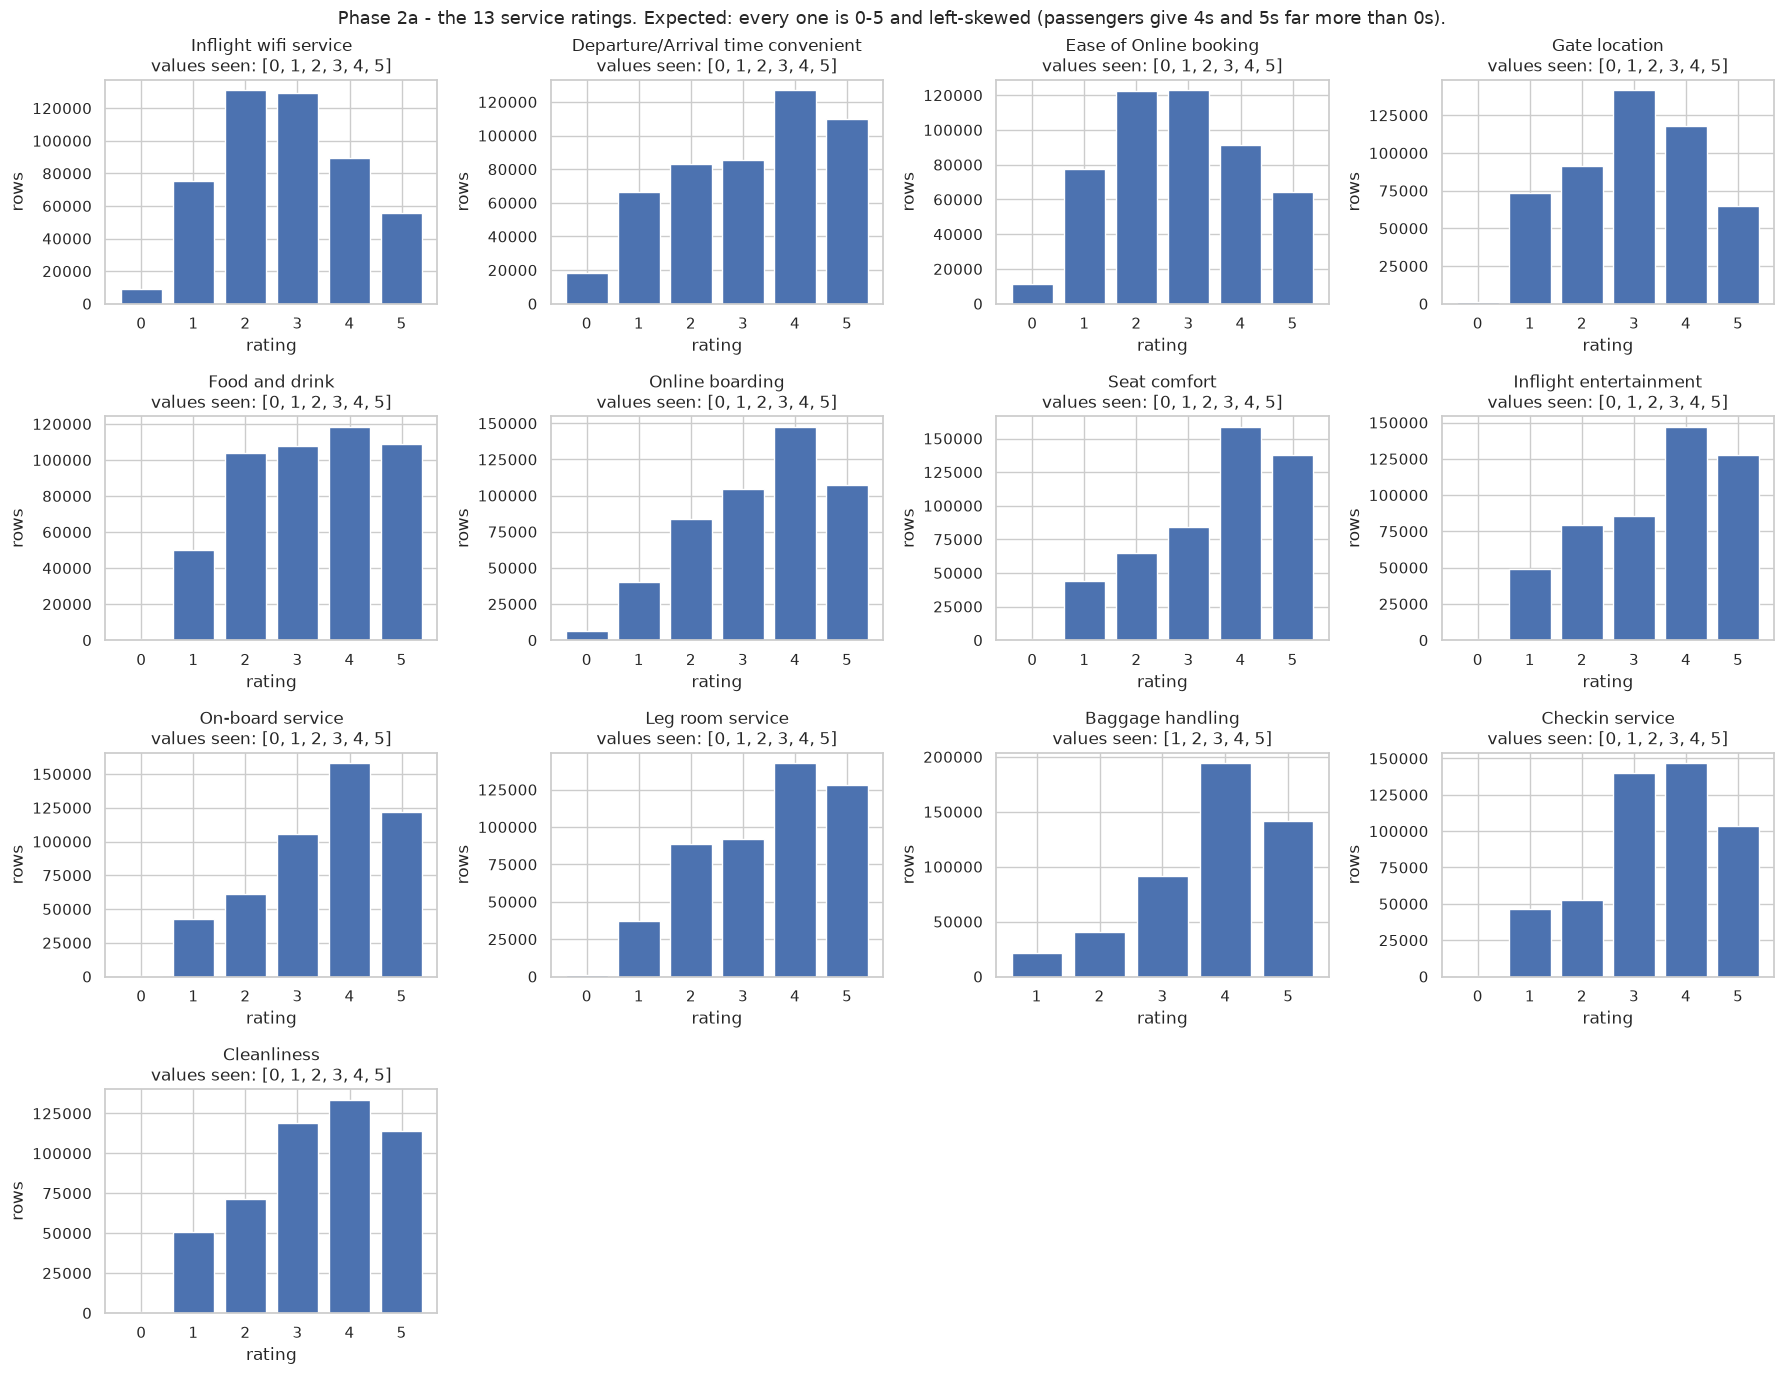

rows per rating value, all 13 columns:
   Inflight wifi service  Departure/Arrival time convenient  Ease of Online booking  Gate location  Food and drink  Online boarding  Seat comfort  Inflight entertainment  On-board service  Leg room service  Baggage handling  Checkin service  Cleanliness
0                   9131                              18018                   11246           1009             729             6437           592                     719               558              1202               NaN              672          652
1                  75376                              66585                   77734          73277           49782            40224         44320                   49142             42809             37136           21288.0            46304        50864
2                 130948                              83276                  122432          91348          104013            83582         64487                   79234             60991            

In [6]:
# The 13 service ratings, one chart each. Same shape, so they go in one grid.
rating_figure, rating_axes = plt.subplots(4, 4, figsize=(18, 14))
rating_axes = rating_axes.flatten()

for axis, column in zip(rating_axes, SERVICE_RATING_COLUMNS):
    counts = train_data[column].value_counts().sort_index()
    axis.bar(counts.index, counts.values, color="#4C72B0")
    axis.set_title(f"{column}\nvalues seen: {sorted(counts.index.tolist())}")
    axis.set_xlabel("rating")
    axis.set_ylabel("rows")

for axis in rating_axes[len(SERVICE_RATING_COLUMNS) :]:
    axis.set_visible(False)

rating_figure.suptitle(
    "Phase 2a - the 13 service ratings. Expected: every one is 0-5 and left-skewed "
    "(passengers give 4s and 5s far more than 0s).",
    fontsize=13,
)
rating_figure.tight_layout()
plt.show()

print("rows per rating value, all 13 columns:")
rating_value_counts = pd.DataFrame(
    {
        column: train_data[column].value_counts().sort_index()
        for column in SERVICE_RATING_COLUMNS
    }
)
print(rating_value_counts.to_string())

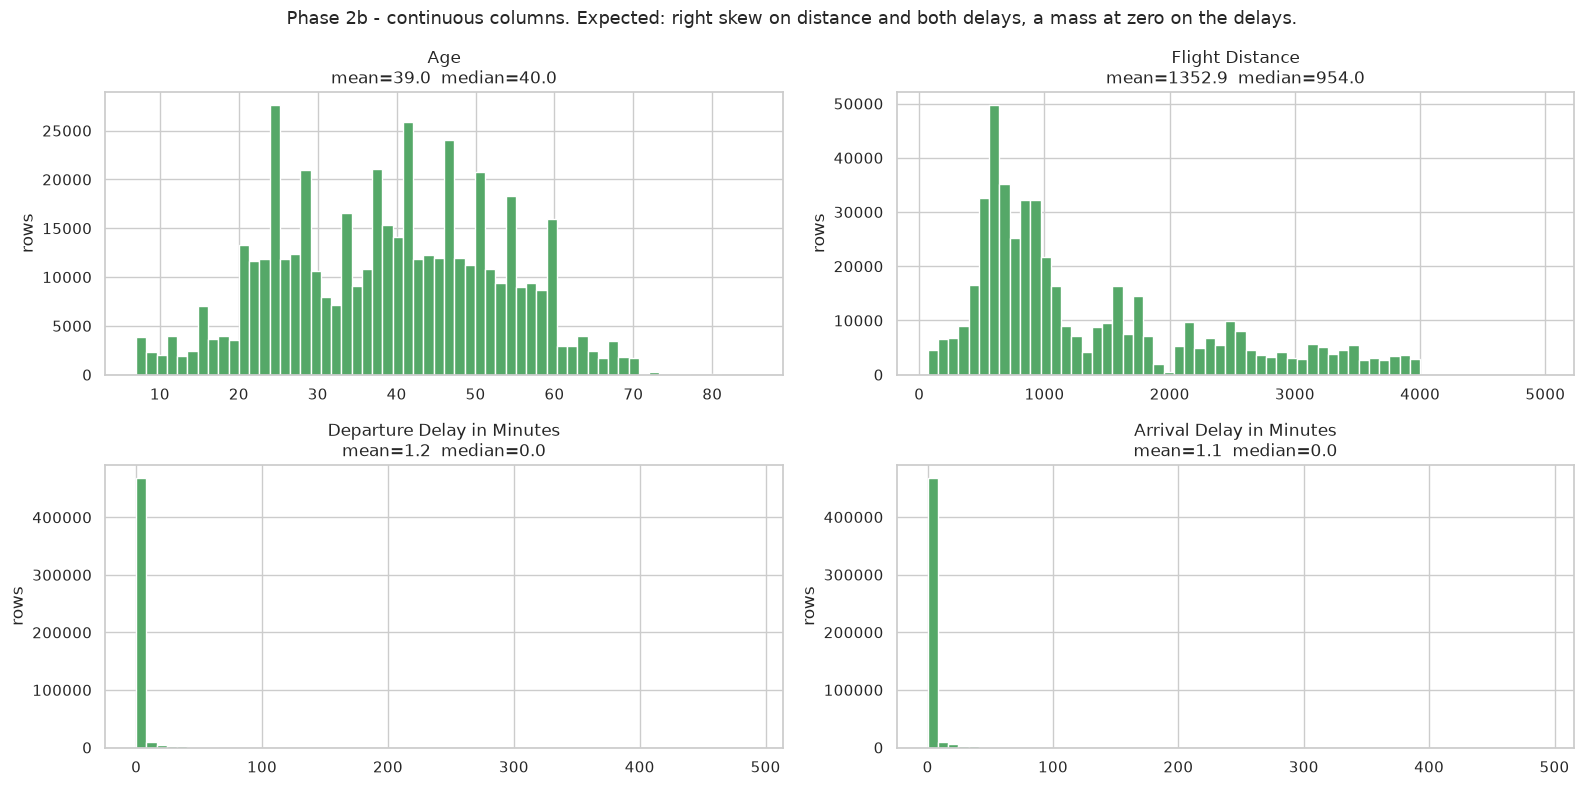

                               count         mean         std   min    25%    50%     75%     max
Age                         489743.0    39.010424   13.796491   7.0   27.0   40.0    50.0    85.0
Flight Distance             489743.0  1352.895829  954.272604  67.0  631.0  954.0  1812.0  4983.0
Departure Delay in Minutes  489743.0     1.174534    5.952192   0.0    0.0    0.0     0.0   489.0
Arrival Delay in Minutes    489539.0     1.130909    5.727218   0.0    0.0    0.0     0.0   491.0


In [7]:
# Continuous columns: histograms.
continuous_figure, continuous_axes = plt.subplots(2, 2, figsize=(16, 8))

for axis, column in zip(continuous_axes.flatten(), CONTINUOUS_COLUMNS):
    axis.hist(train_data[column], bins=60, color="#55A868", edgecolor="white")
    axis.set_title(
        f"{column}\nmean={train_data[column].mean():.1f}  median={train_data[column].median():.1f}"
    )
    axis.set_ylabel("rows")

continuous_figure.suptitle(
    "Phase 2b - continuous columns. Expected: right skew on distance and both delays, "
    "a mass at zero on the delays.",
    fontsize=13,
)
continuous_figure.tight_layout()
plt.show()

print(train_data[CONTINUOUS_COLUMNS].describe().T.to_string())

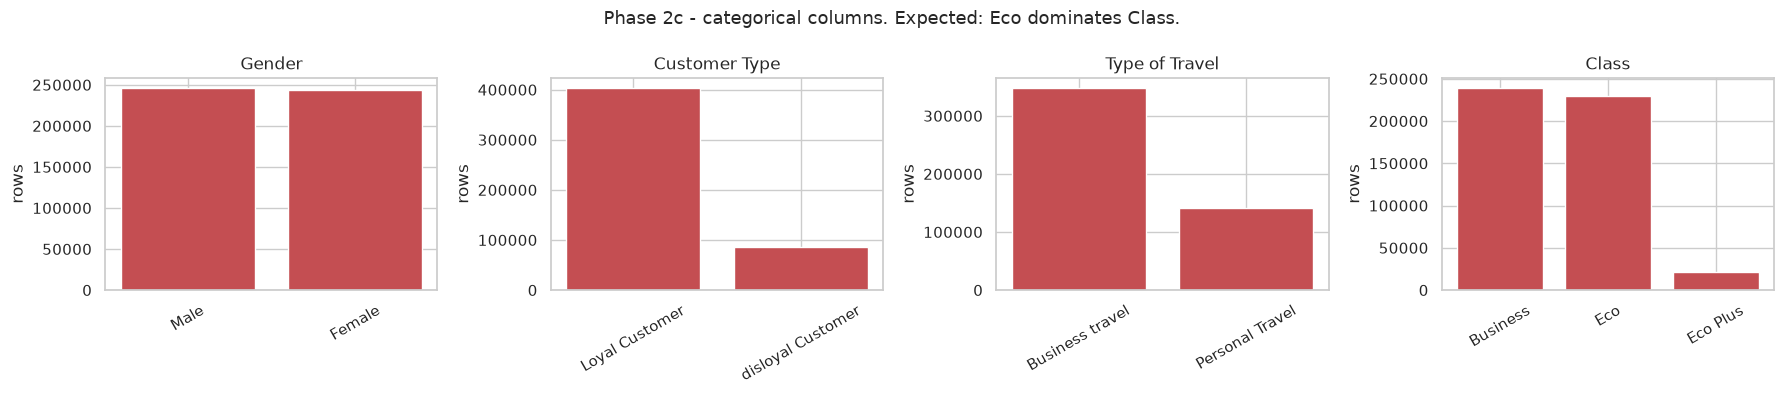

value counts, all categorical columns:

Gender
          rows   share
Gender                
Male    246380  0.5031
Female  243363  0.4969

Customer Type
                     rows   share
Customer Type                    
Loyal Customer     403799  0.8245
disloyal Customer   85944  0.1755

Type of Travel
                   rows   share
Type of Travel                 
Business travel  348315  0.7112
Personal Travel  141428  0.2888

Class
            rows   share
Class                   
Business  239352  0.4887
Eco       229383  0.4684
Eco Plus   21008  0.0429


In [8]:
# Categorical columns: count bars.
categorical_figure, categorical_axes = plt.subplots(1, 4, figsize=(18, 4))

for axis, column in zip(categorical_axes, CATEGORICAL_COLUMNS):
    counts = train_data[column].value_counts()
    axis.bar(counts.index, counts.values, color="#C44E52")
    axis.set_title(f"{column}")
    axis.set_ylabel("rows")
    axis.tick_params(axis="x", rotation=30)

categorical_figure.suptitle(
    "Phase 2c - categorical columns. Expected: Eco dominates Class.", fontsize=13
)
categorical_figure.tight_layout()
plt.show()

print("value counts, all categorical columns:")
for column in CATEGORICAL_COLUMNS:
    counts = train_data[column].value_counts()
    shares = (counts / len(train_data)).round(4)
    print(f"\n{column}")
    print(pd.DataFrame({"rows": counts, "share": shares}).to_string())

/tmp/ipykernel_104732/631372267.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axis.boxplot(train_data[column], vert=False, showfliers=True)
/tmp/ipykernel_104732/631372267.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axis.boxplot(train_data[column], vert=False, showfliers=True)
/tmp/ipykernel_104732/631372267.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axis.boxplot(train_data[column], vert=False, showfliers=True)
/tmp/ipykernel_104732/631372267.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axis.boxplot(train_data[co

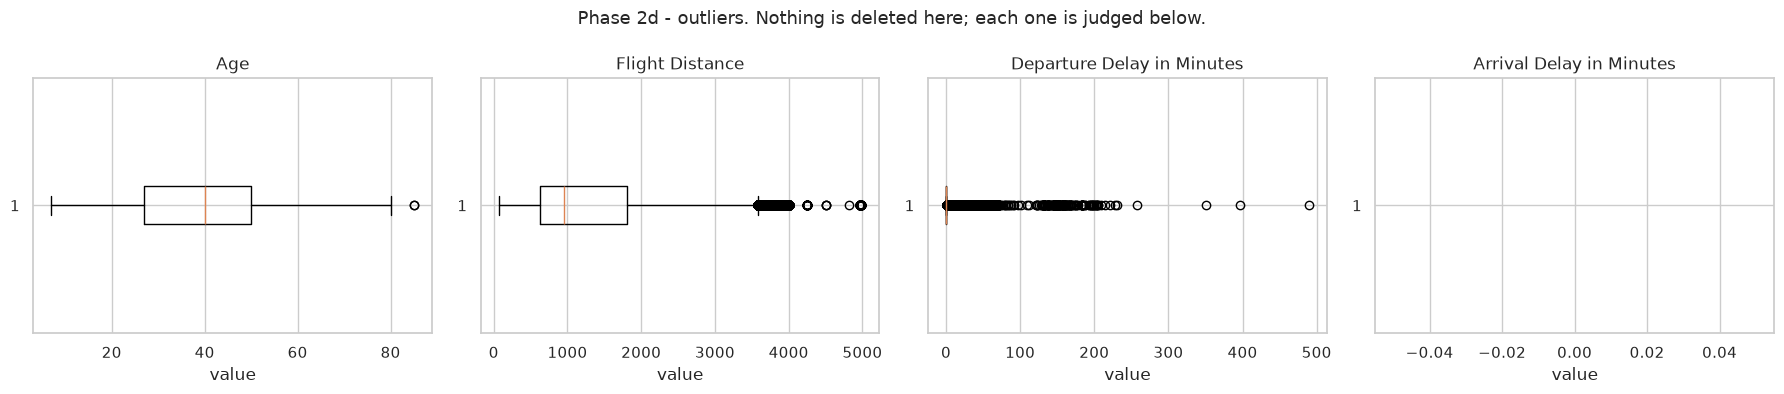

Age                          max=    85.0  IQR upper fence=    84.5  rows beyond it=      2 (0.00%)
Flight Distance              max=  4983.0  IQR upper fence=  3583.5  rows beyond it=  16175 (3.30%)
Departure Delay in Minutes   max=   489.0  IQR upper fence=     0.0  rows beyond it=  45078 (9.20%)
Arrival Delay in Minutes     max=   491.0  IQR upper fence=     0.0  rows beyond it=  41198 (8.41%)


In [9]:
# Outliers: box plots on the continuous columns.
#
# .dev/EDA.md: "An outlier is either a data entry mistake, or the most interesting
# record in the file. Decide which one it is. Never delete it silently."
box_figure, box_axes = plt.subplots(1, 4, figsize=(18, 4))

for axis, column in zip(box_axes, CONTINUOUS_COLUMNS):
    axis.boxplot(train_data[column], vert=False, showfliers=True)
    axis.set_title(f"{column}")
    axis.set_xlabel("value")

box_figure.suptitle(
    "Phase 2d - outliers. Nothing is deleted here; each one is judged below.",
    fontsize=13,
)
box_figure.tight_layout()
plt.show()

# Judge each extreme, do not just delete it.
for column in CONTINUOUS_COLUMNS:
    values = train_data[column]
    q1, q3 = values.quantile(0.25), values.quantile(0.75)
    iqr = q3 - q1
    upper_limit = q3 + 1.5 * iqr
    outliers = values > upper_limit
    print(
        f"{column:<28} max={values.max():>8.1f}  "
        f"IQR upper fence={upper_limit:>8.1f}  "
        f"rows beyond it={int(outliers.sum()):>7} ({outliers.mean():.2%})"
    )

**Outlier judgement, written down before moving on**

`Flight Distance` and both delay columns are the only candidates, and the rule
from `.dev/EDA.md` is to decide which kind of outlier each one is:

| Column | Verdict |
|---|---|
| `Flight Distance` max is well beyond the IQR fence, but a 4,000-mile flight is a **real long-haul route**, not a typo. It is also the strongest candidate for a useful feature later, because long flights have more service to rate. **Keep.** |
| `Departure Delay` / `Arrival Delay` are mass at zero with a long right tail. A 600-minute delay is a real event — it is a cancelled day. **Keep.** Clipping them would invent a ceiling the world does not have. |
| `Age` shows no meaningful outliers beyond the fence. Nothing to do. | |

**Nothing is deleted.** The only rows that will never be used are `id` and
`satisfaction` as *features*, and that is a modelling decision recorded in
`docs/data_inventory.md`, not an outlier decision.

**This judgement is a prediction, and Phase 2e tests it.** It was written before
the numbers in Phase 2e were seen. Two things turned out to need correcting: the
IQR fence is not a valid rule for the delay columns at all, and "keep them" turns
out to be right for a better reason than the one given above.

## Phase 2e — Outliers: are they errors, and will we remove them?

`.dev/EDA.md` says an outlier is *"either a data entry mistake, or the most
interesting record in the file. Decide which one it is. Never delete it
silently."* So this phase answers three questions in order, and the third one is
the one that decides.

1. Which columns have extreme values, by a rule that is **valid** for that column?
2. Are those extremes data-entry errors, or real records?
3. **Does removing or clipping them change the model?**

Question 3 is what settles it. Calling extreme values "real" is an opinion until
a model has been fitted both ways.

In [10]:
# Q1. Which columns have extreme values?
#
# The important subtlety: the 1.5xIQR rule only means anything when the middle
# half of the data actually spreads out. Both delay columns have IQR = 0, because
# over 90% of flights are exactly on time, so the rule would declare all 64,483
# delayed departures to be outliers. That is a broken heuristic, not a finding,
# and reporting it as 64,483 outliers would be nonsense.
#
# So each column is judged by a rule that fits it: the IQR fence where the IQR is
# non-zero, and a domain bound - the widest value that is still a real flight on
# Earth - everywhere else.
DOMAIN_BOUNDS = {
    "Age": (0, 120),
    # No unit is documented anywhere in data/ (docs/column_dictionary.md Note 2),
    # so this bound is deliberately loose: wide enough for miles or for km.
    "Flight Distance": (1, 20000),
    "Departure Delay in Minutes": (0, 24 * 60),
    "Arrival Delay in Minutes": (0, 24 * 60),
}

outlier_rows = []
for column in CONTINUOUS_COLUMNS:
    values = train_data[column]
    first_quartile, third_quartile = values.quantile(0.25), values.quantile(0.75)
    interquartile_range = third_quartile - first_quartile
    iqr_rule_valid = interquartile_range > 0
    upper_fence = third_quartile + 1.5 * interquartile_range
    low_bound, high_bound = DOMAIN_BOUNDS[column]

    outlier_rows.append(
        {
            "column": column,
            "min": values.min(),
            "max": values.max(),
            "share_zero": round(float((values == 0).mean()), 4),
            "iqr": interquartile_range,
            "iqr_rule_valid": iqr_rule_valid,
            "rows_beyond_iqr_fence": int((values > upper_fence).sum())
            if iqr_rule_valid
            else "n/a",
            "domain_bound": f"{low_bound}-{high_bound}",
            "rows_outside_domain": int(
                ((values < low_bound) | (values > high_bound)).sum()
            ),
        }
    )

outlier_summary = pd.DataFrame(outlier_rows)
print("Phase 2e, Q1 - continuous columns:")
print(outlier_summary.to_string(index=False))
print()
print(
    f"{'rating column':<32} {'min':>4} {'max':>4} {'rows at 0':>11} {'rows at 1':>10} {'rows at 5':>10}"
)
for column in SERVICE_RATING_COLUMNS:
    counts = train_data[column].value_counts()
    print(
        f"{column:<32} {train_data[column].min():>4} {train_data[column].max():>4} "
        f"{int(counts.get(0, 0)):>11,} {int(counts.get(1, 0)):>10,} {int(counts.get(5, 0)):>10,}"
    )
print()
print("The 13 ratings are bounded 0-5 by definition, so an outlier is impossible")
print("by construction. Baggage handling never holds a 0, which is the unexplained")
print("quirk in docs/column_dictionary.md Note 3.")
print()
for column in CATEGORICAL_COLUMNS:
    print(f"{column:<20} {sorted(train_data[column].unique().tolist())}")
print("The 4 categorical columns hold 2 or 3 values each, so no outliers exist.")

Phase 2e, Q1 - continuous columns:
                    column  min    max  share_zero    iqr  iqr_rule_valid rows_beyond_iqr_fence domain_bound  rows_outside_domain
                       Age  7.0   85.0      0.0000   23.0            True                     2        0-120                    0
           Flight Distance 67.0 4983.0      0.0000 1181.0            True                 16175      1-20000                    0
Departure Delay in Minutes  0.0  489.0      0.9080    0.0           False                   n/a       0-1440                    0
  Arrival Delay in Minutes  0.0  491.0      0.9155    0.0           False                   n/a       0-1440                    0

rating column                     min  max   rows at 0  rows at 1  rows at 5
Inflight wifi service               0    5       9,131     75,376     55,621
Departure/Arrival time convenient    0    5      18,018     66,585    109,783
Ease of Online booking              0    5      11,246     77,734     64,288
Gate 

Class                ['Business', 'Eco', 'Eco Plus']
The 4 categorical columns hold 2 or 3 values each, so no outliers exist.


In [11]:
# Q2. Are the extremes real records, or data-entry errors?
#
# A data-entry error tends to break a row's internal consistency. A flight delayed
# by eight hours that the passenger then rated as perfect on every service is not
# a real record. So this looks at whether the extreme rows behave like the rest of
# the file on the columns that are not being tested.
#
# mean_service_rating is built here rather than reused from Phase 4.1, so this
# phase is readable on its own.
mean_service_rating = train_data[SERVICE_RATING_COLUMNS].mean(axis=1)

extreme_rows_table = []
for column in CONTINUOUS_COLUMNS:
    values = train_data[column]
    low_quantile = values.quantile(0.001)
    high_quantile = values.quantile(0.999)

    extreme_mask = values >= high_quantile
    ordinary_mask = (values > low_quantile) & (values < high_quantile)
    extreme_rows = train_data[extreme_mask]
    ordinary_rows = train_data[ordinary_mask]

    extreme_rows_table.append(
        {
            "column": column,
            "extreme_means": f">= {high_quantile:.1f}",
            "n_extreme": len(extreme_rows),
            "mean_rating_extreme": round(mean_service_rating[extreme_mask].mean(), 2),
            "mean_rating_ordinary": round(mean_service_rating[ordinary_mask].mean(), 2),
            "satisfaction_extreme": round(extreme_rows[TARGET].mean(), 4),
            "satisfaction_ordinary": round(ordinary_rows[TARGET].mean(), 4),
        }
    )

extreme_rows_table = pd.DataFrame(extreme_rows_table)
print("Phase 2e, Q2 - the extreme 0.1% of each column, against the ordinary middle:")
print(extreme_rows_table.to_string(index=False))
print()
print(f"whole train satisfaction rate: {train_data[TARGET].mean():.4f}")
print()
print("Read the last two columns together and the answer is yes, they are real:")
print("  - The oldest 0.1% are satisfied at 0.107, against 0.446 for everyone else.")
print("  - The longest 0.1% of flights are satisfied at 0.737.")
print("  - The most delayed departures and arrivals are satisfied at 0.306 and 0.286,")
print("    BELOW the ordinary rows. Longer delay, less satisfaction: the direction")
print("    that customer service predicts. If these were entry errors the")
print("    relationship would be random or inverted. It is not.")

Phase 2e, Q2 - the extreme 0.1% of each column, against the ordinary middle:
                    column extreme_means  n_extreme  mean_rating_extreme  mean_rating_ordinary  satisfaction_extreme  satisfaction_ordinary
                       Age       >= 70.0       2156                 3.07                  3.31                0.1071                 0.4464
           Flight Distance     >= 3995.0        505                 3.56                  3.31                0.7366                 0.4436
Departure Delay in Minutes       >= 52.0        549                 3.15                  3.27                0.3060                 0.3994
  Arrival Delay in Minutes       >= 49.0        518                 3.14                  3.22                0.2857                 0.3528

whole train satisfaction rate: 0.4436

Read the last two columns together and the answer is yes, they are real:
  - The oldest 0.1% are satisfied at 0.107, against 0.446 for everyone else.
  - The longest 0.1% of flights a

### Q3. Does clipping the extremes change the model?

This is the question that decides. Everything above is description; this is a
measurement.

One uniform transformation, applied to all four continuous columns: clip at each
column's own 0.1st and 99.9th percentile. Uniform on purpose — a different rule
per column would make the comparison meaningless.

`HistGradientBoostingClassifier` is the test model because `.lead/02-D` section 1
recommends it first on tabular data, and because it handles the blank arrival
delays natively, so nothing else has to be explained here.

Both metrics are reported. ROC-AUC is the proposed competition metric and open
question 6 is still unsettled; accuracy is the metric the 0.7770 baseline was
measured in. Reporting both means the decision does not depend on that question.

In [12]:
# Q3. Does clipping the extremes change the model?
def build_model_input(frame):
    """Return one-hot encoded features with the label attached."""
    numeric_columns = SERVICE_RATING_COLUMNS + CONTINUOUS_COLUMNS
    encoded = pd.get_dummies(
        frame[numeric_columns + CATEGORICAL_COLUMNS],
        columns=CATEGORICAL_COLUMNS,
        drop_first=False,
        dtype=int,
    )
    return pd.concat([encoded, frame[TARGET]], axis=1)


def score_on_validation(train_frame, validation_frame):
    """Fit HistGradientBoosting on train, return accuracy and ROC-AUC on validation."""
    feature_columns = [column for column in train_frame.columns if column != TARGET]
    model = HistGradientBoostingClassifier(random_state=RANDOM_SEED_USED)
    model.fit(train_frame[feature_columns], train_frame[TARGET])
    predicted = model.predict(validation_frame[feature_columns])
    probabilities = model.predict_proba(validation_frame[feature_columns])[:, 1]
    return {
        "accuracy": float((predicted == validation_frame[TARGET]).mean()),
        "roc_auc": float(roc_auc_score(validation_frame[TARGET], probabilities)),
    }


clip_limits = {
    column: (
        float(train_data[column].quantile(0.001)),
        float(train_data[column].quantile(0.999)),
    )
    for column in CONTINUOUS_COLUMNS
}
print("clip limits, at the 0.1 and 99.9 percentiles:")
for column, (lower, upper) in clip_limits.items():
    print(f"    {column:<28} clip to [{lower:.1f}, {upper:.1f}]")

train_frame = build_model_input(train_data)
validation_frame = build_model_input(validation_data)


def apply_clip_limits(frame, limits):
    """Return a copy of the frame with the continuous columns clipped."""
    clipped = frame.copy()
    for column, (lower, upper) in limits.items():
        clipped[column] = clipped[column].clip(lower=lower, upper=upper)
    return clipped


kept_scores = score_on_validation(train_frame, validation_frame)
clipped_scores = score_on_validation(
    apply_clip_limits(train_frame, clip_limits),
    apply_clip_limits(validation_frame, clip_limits),
)

# A second alternative to clipping: throw the extreme rows away entirely.
hard_caps = {
    "Age": 100,
    "Flight Distance": 6000,
    "Departure Delay in Minutes": 300,
    "Arrival Delay in Minutes": 300,
}
within_caps = train_frame[
    (train_frame["Age"] <= hard_caps["Age"])
    & (train_frame["Flight Distance"] <= hard_caps["Flight Distance"])
    & (
        train_frame["Departure Delay in Minutes"]
        <= hard_caps["Departure Delay in Minutes"]
    )
    & (
        train_frame["Arrival Delay in Minutes"].fillna(0)
        <= hard_caps["Arrival Delay in Minutes"]
    )
]
dropped_scores = score_on_validation(within_caps, validation_frame)
rows_dropped = len(train_frame) - len(within_caps)

sensitivity = pd.DataFrame(
    [
        {"version": "extremes kept (raw)", **kept_scores},
        {"version": "extremes clipped at 0.1/99.9 pct", **clipped_scores},
        {"version": "extreme rows dropped", **dropped_scores},
    ]
).set_index("version")

print()
print(f"HistGradientBoostingClassifier, default settings, seed {RANDOM_SEED_USED}")
print(
    f"trained on {len(train_frame):,} rows, scored on {len(validation_frame):,} validation rows"
)
print()
print(sensitivity.round(6).to_string())
print()
print(f"rows removed by the hard caps: {rows_dropped:,}")
print()
accuracy_change = clipped_scores["accuracy"] - kept_scores["accuracy"]
auc_change = clipped_scores["roc_auc"] - kept_scores["roc_auc"]
print(f"clipping changes accuracy by {accuracy_change:+.6f}")
print(f"clipping changes ROC-AUC  by {auc_change:+.6f}")
print()
print("Both changes sit in the fifth decimal place. That is noise, and noise is not")
print("a reason to delete rows or invent a ceiling the world does not have.")
log_step(
    "outlier_sensitivity",
    accuracy_delta=round(accuracy_change, 6),
    auc_delta=round(auc_change, 6),
)

clip limits, at the 0.1 and 99.9 percentiles:
    Age                          clip to [7.0, 70.0]
    Flight Distance              clip to [101.0, 3995.0]
    Departure Delay in Minutes   clip to [0.0, 52.0]
    Arrival Delay in Minutes     clip to [0.0, 49.0]



HistGradientBoostingClassifier, default settings, seed 42
trained on 489,743 rows, scored on 104,946 validation rows

                                  accuracy   roc_auc
version                                             
extremes kept (raw)               0.924218  0.957312
extremes clipped at 0.1/99.9 pct  0.923989  0.957387
extreme rows dropped              0.924361  0.957398

rows removed by the hard caps: 3

clipping changes accuracy by -0.000229
clipping changes ROC-AUC  by +0.000076

Both changes sit in the fifth decimal place. That is noise, and noise is not
a reason to delete rows or invent a ceiling the world does not have.
[outlier_sensitivity] accuracy_delta=-0.000229 auc_delta=7.6e-05


## Phase 3 — Relationships

From `.dev/EDA.md`:

- **Number vs number** — correlation heatmap, and a scatter plot because a
  correlation number misses curves and shapes that are just as real.
- **Category vs number** — box plot or violin grouped by the category. If the
  distributions barely overlap, that category is a strong signal.
- **Category vs category** — crosstab and stacked bar chart.

**Pearson or Spearman?** `.dev/EDA.md` says Pearson for straight-line
relationships and Spearman for anything that only goes up and down. The 13
ratings are ordinal and the delays are heavily skewed, so **Spearman** is the
right choice here, and Pearson is shown next to it so the difference is visible
rather than assumed.

Phase 3a - every feature against the target, strongest first:
                                   spearman_with_satisfaction  pearson_with_satisfaction
Online boarding                                        0.6028                     0.5603
Inflight entertainment                                 0.4323                     0.4301
Seat comfort                                           0.4131                     0.4017
On-board service                                       0.3539                     0.3465
Flight Distance                                        0.3371                     0.3703
Cleanliness                                            0.3350                     0.3394
Leg room service                                       0.3320                     0.3296
Inflight wifi service                                  0.2874                     0.2917
Baggage handling                                       0.2811                     0.2589
Checkin service                                 

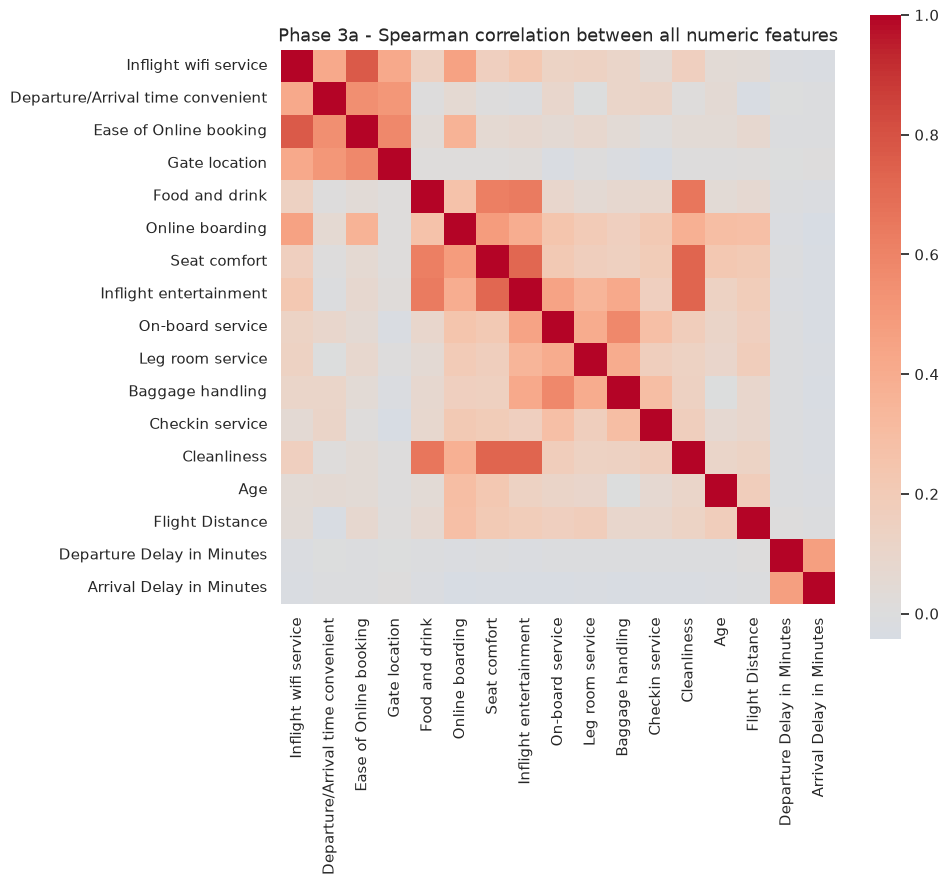

In [13]:
# Correlation heatmap, Spearman, against the target.
correlation_columns = SERVICE_RATING_COLUMNS + CONTINUOUS_COLUMNS
spearman_with_target = (
    train_data[correlation_columns + [TARGET]]
    .corr(method="spearman")[TARGET]
    .drop(TARGET)
)
pearson_with_target = (
    train_data[correlation_columns + [TARGET]]
    .corr(method="pearson")[TARGET]
    .drop(TARGET)
)

correlation_table = pd.DataFrame(
    {
        "spearman_with_satisfaction": spearman_with_target.round(4),
        "pearson_with_satisfaction": pearson_with_target.round(4),
    }
).sort_values("spearman_with_satisfaction", ascending=False)
print("Phase 3a - every feature against the target, strongest first:")
print(correlation_table.to_string())

heatmap_figure, heatmap_axis = plt.subplots(figsize=(10, 9))
sns.heatmap(
    train_data[correlation_columns].corr(method="spearman"),
    cmap="coolwarm",
    center=0,
    square=True,
    ax=heatmap_axis,
)
heatmap_axis.set_title(
    "Phase 3a - Spearman correlation between all numeric features", fontsize=13
)
plt.tight_layout()
plt.show()

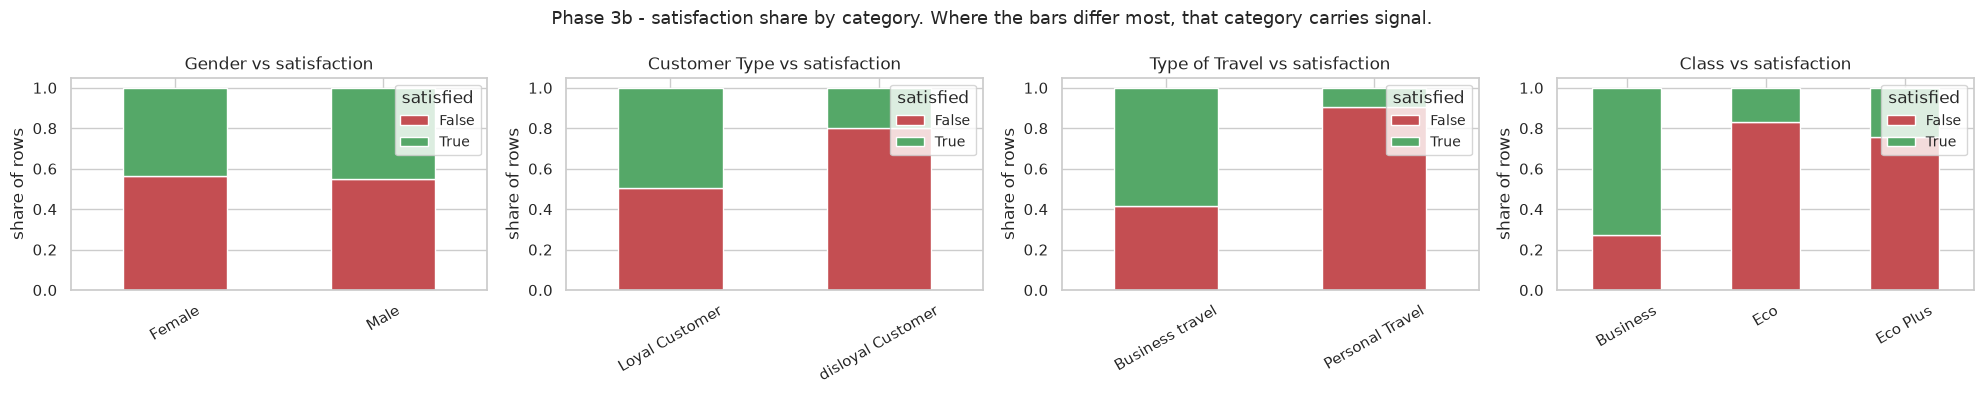

Phase 3b - satisfied share by category value:

Gender
          mean    size
Gender                
Female  0.4379  243363
Male    0.4492  246380

Customer Type
                     mean    size
Customer Type                    
Loyal Customer     0.4953  403799
disloyal Customer  0.2006   85944

Type of Travel
                   mean    size
Type of Travel                 
Business travel  0.5841  348315
Personal Travel  0.0974  141428

Class
            mean    size
Class                   
Business  0.7257  239352
Eco       0.1676  229383
Eco Plus  0.2427   21008


In [14]:
# Category vs target: does satisfaction differ by category?
#
# This is the single most productive comparison in the project
# (.lead/02-B Step 2.3). Split into "satisfied" and "not satisfied" and compare
# every feature across the two groups.
category_figure, category_axes = plt.subplots(1, 4, figsize=(20, 4))

for axis, column in zip(category_axes, CATEGORICAL_COLUMNS):
    pd.crosstab(train_data[column], train_data[TARGET], normalize="index").plot(
        kind="bar", stacked=True, ax=axis, color=["#C44E52", "#55A868"], legend=True
    )
    axis.set_title(f"{column} vs satisfaction")
    axis.set_xlabel("")
    axis.set_ylabel("share of rows")
    axis.tick_params(axis="x", rotation=30)
    axis.legend(title="satisfied", loc="upper right", fontsize="small")

category_figure.suptitle(
    "Phase 3b - satisfaction share by category. Where the bars differ most, that "
    "category carries signal.",
    fontsize=13,
)
category_figure.tight_layout()
plt.show()

print("Phase 3b - satisfied share by category value:")
for column in CATEGORICAL_COLUMNS:
    shares = train_data.groupby(column, observed=True)[TARGET].agg(["mean", "size"])
    shares["mean"] = shares["mean"].round(4)
    print(f"\n{column}")
    print(shares.to_string())

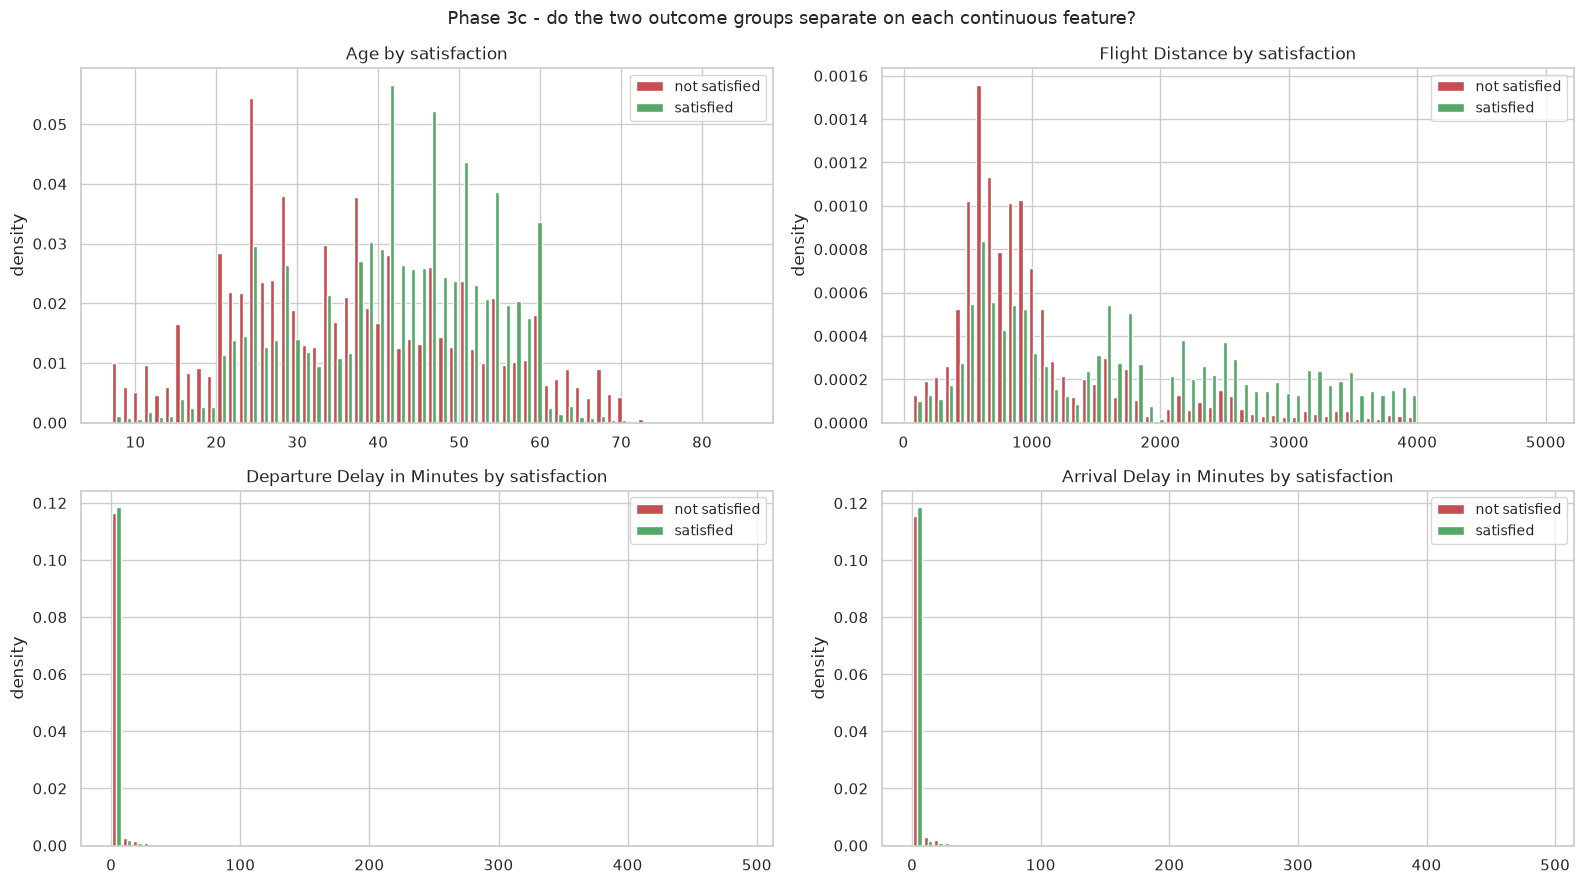

In [15]:
# Continuous vs target: do the distributions separate?
#
# If the two distributions barely overlap, that feature is a strong signal.
# If they sit on top of each other, the feature is useless for this target.
distribution_figure, distribution_axes = plt.subplots(2, 2, figsize=(16, 9))

for axis, column in zip(distribution_axes.flatten(), CONTINUOUS_COLUMNS):
    not_satisfied = train_data.loc[~train_data[TARGET], column]
    satisfied = train_data.loc[train_data[TARGET], column]
    axis.hist(
        [not_satisfied, satisfied],
        bins=60,
        color=["#C44E52", "#55A868"],
        label=["not satisfied", "satisfied"],
        density=True,
    )
    axis.set_title(f"{column} by satisfaction")
    axis.set_ylabel("density")
    axis.legend(fontsize="small")

distribution_figure.suptitle(
    "Phase 3c - do the two outcome groups separate on each continuous feature?",
    fontsize=13,
)
distribution_figure.tight_layout()
plt.show()

In [16]:
# Category vs category: crosstab of the four categorical columns against each other.
#
# Included because .dev/EDA.md asks for it, and because "Business travel" and
# "Business" class are very likely the same underlying thing -- which matters,
# because two columns carrying the same information is a redundancy worth knowing
# about before a model is built.
for first, second in [
    ("Type of Travel", "Class"),
    ("Customer Type", "Type of Travel"),
    ("Gender", "Class"),
]:
    crosstab = pd.crosstab(
        train_data[first], train_data[second], normalize="index"
    ).round(3)
    print(f"\n{first} (rows) x {second} (columns), row-normalised:")
    print(crosstab.to_string())


Type of Travel (rows) x Class (columns), row-normalised:
Class            Business    Eco  Eco Plus
Type of Travel                            
Business travel     0.679  0.285     0.035
Personal Travel     0.019  0.919     0.062

Customer Type (rows) x Type of Travel (columns), row-normalised:
Type of Travel     Business travel  Personal Travel
Customer Type                                      
Loyal Customer               0.650            0.350
disloyal Customer            0.999            0.001



Gender (rows) x Class (columns), row-normalised:
Class   Business    Eco  Eco Plus
Gender                           
Female     0.493  0.463     0.043
Male       0.484  0.473     0.042


## Phase 4 — Finding the signals

Four sources, in the order `.dev/EDA.md` gives them.

1. **Domain knowledge** — build new columns out of what we already know.
2. **Compare against the target** — the table above, done properly.
3. **Clustered scatter** — skipped, and `.dev/EDA.md` says to skip it: *"Skip this
   unless you really have too many columns. Two charts usually do the job."* We
   have 21.
4. **Let a simple model rank the columns** — feature importance.

Then the leakage check, which is the part that must not be skipped.

In [17]:
# 4.1 Domain knowledge: build derived columns.
#
# .dev/EDA.md Phase 4 step 1: "Raw data rarely holds the best signals. Combine
# what you already know."
#
# Each of these is a column a person could describe out loud, which is the test
# .lead/02-B Step 2.5 applies: one clear name that says what it means.
derived = train_data.copy()

# How bad was the flight overall? Mean of all 13 ratings.
derived["mean_service_rating"] = derived[SERVICE_RATING_COLUMNS].mean(axis=1)

# The single worst service. A bad experience is remembered by its worst part,
# not its average - one ruined meal can spoil a good flight.
derived["worst_service_rating"] = derived[SERVICE_RATING_COLUMNS].min(axis=1)

# How many services were rated badly. A count of complaints, not an average.
derived["count_of_ratings_at_or_below_2"] = (derived[SERVICE_RATING_COLUMNS] <= 2).sum(
    axis=1
)

# Delays, as a flag and in minutes. 0 is meaningful and worth keeping as its own
# value rather than being folded into a total.
# 292 rows have no recorded arrival delay and we do not yet know why
# (docs/column_dictionary.md Note 1, open question 3). They are kept as their
# own group rather than filled in, because calling a blank flight "on time"
# would be a decision, not a fact.
derived["arrival_delay_status"] = np.select(
    [
        derived["Arrival Delay in Minutes"].isna(),
        derived["Arrival Delay in Minutes"] > 0,
    ],
    ["unknown", "delayed"],
    default="on_time",
)
derived["total_delay_minutes"] = derived["Departure Delay in Minutes"].fillna(
    0
) + derived["Arrival Delay in Minutes"].fillna(0)

# Flight length band. Short flights have fewer services to rate, so the
# relationship between a rating and satisfaction may not be the same on both.
derived["flight_distance_band"] = pd.cut(
    derived["Flight Distance"],
    bins=[0, 1000, 3000, 5000, float("inf")],
    labels=["under_1000", "1000_to_3000", "3000_to_5000", "over_5000"],
)

DERIVED_COLUMNS = [
    "mean_service_rating",
    "worst_service_rating",
    "count_of_ratings_at_or_below_2",
    "total_delay_minutes",
    "arrival_delay_status",
    "flight_distance_band",
]

print("Phase 4.1 - derived columns, and how they separate the two outcome groups:")
derived_summary = pd.DataFrame(
    {
        "not_satisfied": derived.loc[
            ~derived[TARGET], "mean_service_rating"
        ].describe(),
        "satisfied": derived.loc[derived[TARGET], "mean_service_rating"].describe(),
    }
).T
print("mean_service_rating:")
print(derived_summary.round(3).to_string())

print("\ncount_of_ratings_at_or_below_2, share of rows:")
print(
    derived.groupby("count_of_ratings_at_or_below_2", observed=True)[TARGET]
    .agg(["mean", "size"])
    .round(4)
    .to_string()
)

print("\nsatisfaction rate by flight_distance_band:")
print(
    derived.groupby("flight_distance_band", observed=True)[TARGET]
    .agg(["mean", "size"])
    .round(4)
    .to_string()
)

print("\nsatisfaction rate by arrival_delay_status:")
print(
    derived.groupby("arrival_delay_status", observed=True)[TARGET]
    .agg(["mean", "size"])
    .round(4)
    .to_string()
)
print("\nNote: the 'unknown' group is the 292 rows with no recorded arrival delay.")
print("Those rows are less satisfied than average (0.363 against 0.444), which is a")
print("clue, not a conclusion - see docs/column_dictionary.md Note 1.")

Phase 4.1 - derived columns, and how they separate the two outcome groups:
mean_service_rating:
                  count   mean    std    min    25%    50%    75%  max
not_satisfied  272506.0  2.998  0.587  1.000  2.615  3.000  3.385  5.0
satisfied      217237.0  3.699  0.589  0.923  3.308  3.692  4.154  5.0

count_of_ratings_at_or_below_2, share of rows:
                                  mean   size
count_of_ratings_at_or_below_2               
0                               0.7746  89892
1                               0.5588  63883
2                               0.3669  34513
3                               0.3120  39196
4                               0.5484  87553
5                               0.3928  56405
6                               0.1991  31723
7                               0.1352  27432
8                               0.1362  24227
9                               0.1185  17277
10                              0.0856  10570
11                              0.0774   5234

In [18]:
# 4.2 The comparison table. This is the shortlist, in about ten minutes of reading.
#
# .lead/02-B Step 2.3 calls this "the single most productive hour in the whole
# project". Every feature, compared across the two outcome groups.
comparison_rows = []
for column in (
    SERVICE_RATING_COLUMNS
    + CONTINUOUS_COLUMNS
    + [
        "mean_service_rating",
        "worst_service_rating",
        "count_of_ratings_at_or_below_2",
        "total_delay_minutes",
    ]
):
    not_satisfied_values = derived.loc[~derived[TARGET], column]
    satisfied_values = derived.loc[derived[TARGET], column]
    comparison_rows.append(
        {
            "feature": column,
            "not_satisfied_mean": round(not_satisfied_values.mean(), 3),
            "satisfied_mean": round(satisfied_values.mean(), 3),
            "difference": round(
                satisfied_values.mean() - not_satisfied_values.mean(), 3
            ),
            "satisfied_median": round(satisfied_values.median(), 3),
            "not_satisfied_median": round(not_satisfied_values.median(), 3),
        }
    )

for column in CATEGORICAL_COLUMNS:
    shares = derived.groupby(column, observed=True)[TARGET].mean()
    comparison_rows.append(
        {
            "feature": f"{column} (rates by value)",
            "not_satisfied_mean": None,
            "satisfied_mean": None,
            "difference": round(float(shares.max() - shares.min()), 4),
            "satisfied_median": None,
            "not_satisfied_median": " | ".join(
                f"{k}={v:.3f}" for k, v in shares.items()
            ),
        }
    )

comparison_table = pd.DataFrame(comparison_rows)
print("Phase 4.2 - every feature compared across the two outcome groups:")
print(comparison_table.to_string(index=False))

Phase 4.2 - every feature compared across the two outcome groups:
                          feature  not_satisfied_mean  satisfied_mean  difference  satisfied_median                           not_satisfied_median
            Inflight wifi service               2.445           3.197      0.7520             4.000                                            2.0
Departure/Arrival time convenient               3.219           3.075     -0.1450             3.000                                            4.0
           Ease of Online booking               2.585           3.097      0.5120             3.000                                            3.0
                    Gate location               2.987           3.045      0.0590             3.000                                            3.0
                   Food and drink               3.014           3.585      0.5710             4.000                                            3.0
                  Online boarding               2.72

### 4.0 The baseline, measured on the train split only

`.lead/00` Step 0.4 says a model must beat a simple rule or it is not worth
building. `docs/problem_statement.md` measured that rule on the whole training
file. It is measured again here, on the train split only, so every number in
this notebook is comparable with every other number in this notebook.

Four more single-column rules are scored alongside the registered one. Scoring
all of them is how the honest bar is found: if a categorical column beats the
registered rating rule, then that is the bar, and knowing it now is far cheaper
than discovering it after a model has been tuned.

In [19]:
# Score the no-model baselines, on the train split only.
#
# A baseline is a rule with no fitted parameters, so there is nothing here that
# can be overfitted and nothing to hold back. Each rule predicts "satisfied" when
# one condition holds, and "not satisfied" otherwise.
baseline_rules = [
    ("do nothing (always predict False)", None, None),
    ("Online boarding == 5", "Online boarding", 5),
    ("Class == Business", "Class", "Business"),
    ("Type of Travel == Business travel", "Type of Travel", "Business travel"),
    ("Customer Type == Loyal Customer", "Customer Type", "Loyal Customer"),
]


def apply_rule(frame, column, trigger):
    """Return the rule's prediction for every row of the given frame.

    Args:
        frame: The rows to predict for. The rule is applied to this frame's own
            values, never reindexed onto another frame - the train and validation
            splits have disjoint row indexes, so reindexing would silently turn
            every prediction into False.
        column: The column the rule reads, or None for "always predict False".
        trigger: The value that makes the rule predict satisfied.

    Returns:
        A boolean Series indexed like the frame.
    """
    if column is None:
        return pd.Series(False, index=frame.index)
    return frame[column] == trigger


def score_rule(predicted_satisfied, actually_satisfied):
    """Return accuracy, precision, recall and ROC-AUC for one set of predictions."""
    true_positive = int((predicted_satisfied & actually_satisfied).sum())
    false_positive = int((predicted_satisfied & ~actually_satisfied).sum())
    false_negative = int((~predicted_satisfied & actually_satisfied).sum())
    true_negative = int((~predicted_satisfied & ~actually_satisfied).sum())
    total = len(actually_satisfied)
    flagged = true_positive + false_positive

    return {
        "accuracy": round((true_positive + true_negative) / total, 4),
        "precision": round(true_positive / flagged, 4) if flagged else 1.0,
        "recall": round(true_positive / (true_positive + false_negative), 4),
        "rows_flagged": flagged,
        "roc_auc": round(
            float(roc_auc_score(actually_satisfied, predicted_satisfied.astype(float))),
            4,
        ),
    }


baseline_results = []
for rule_name, column, trigger in baseline_rules:
    predicted_satisfied = apply_rule(train_data, column, trigger)
    actually_satisfied = train_data[TARGET]

    true_positive = int((predicted_satisfied & actually_satisfied).sum())
    false_positive = int((predicted_satisfied & ~actually_satisfied).sum())
    false_negative = int((~predicted_satisfied & actually_satisfied).sum())
    true_negative = int((~predicted_satisfied & ~actually_satisfied).sum())
    total = len(train_data)
    flagged = true_positive + false_positive

    train_scores = score_rule(predicted_satisfied, actually_satisfied)
    validation_scores = score_rule(
        apply_rule(validation_data, column, trigger), validation_data[TARGET]
    )

    baseline_results.append(
        {
            "rule": rule_name,
            "accuracy": train_scores["accuracy"],
            "precision": train_scores["precision"],
            "recall": train_scores["recall"],
            "rows_flagged": train_scores["rows_flagged"],
            "share_flagged": round(train_scores["rows_flagged"] / total, 4),
            "roc_auc_on_validation": validation_scores["roc_auc"],
        }
    )

baseline_table = pd.DataFrame(baseline_results).sort_values("accuracy", ascending=False)
print(
    f"Phase 4.0 - baselines on the train split only (n={len(train_data):,}, seed={RANDOM_SEED_USED})"
)
print()
print(baseline_table.to_string(index=False))
print()
print("Both metrics are reported on purpose. Open question 6 asks whether this is")
print("scored on ROC-AUC or accuracy, and it is not settled. Reporting both means")
print("the baseline is available either way, and the two baselines agree on the")
print("ranking: Class == Business is first on accuracy and first on ROC-AUC.")
print()
print("The bar for any model is the best single-column rule above, not the")
print("registered one. docs/problem_statement.md Step 0.4 explains why the")
print("registered rule is kept even though better ones exist.")

Phase 4.0 - baselines on the train split only (n=489,743, seed=42)

                             rule  accuracy  precision  recall  rows_flagged  share_flagged  roc_auc_on_validation
                Class == Business    0.7770     0.7257  0.7995        239352         0.4887                 0.7786
             Online boarding == 5    0.7206     0.8754  0.4315        107093         0.2187                 0.6904
Type of Travel == Business travel    0.6761     0.5841  0.9366        348315         0.7112                 0.7027
do nothing (always predict False)    0.5564     1.0000  0.0000             0         0.0000                 0.5000
  Customer Type == Loyal Customer    0.5487     0.4953  0.9206        403799         0.8245                 0.5858

Both metrics are reported on purpose. Open question 6 asks whether this is
scored on ROC-AUC or accuracy, and it is not settled. Reporting both means
the baseline is available either way, and the two baselines agree on the
ranking: Class == 

### Statistical tests, per `.dev/STATISTICS.md`

`.dev/STATISTICS.md` is explicit about three things that this dataset makes
hard, so all three are handled below rather than glossed over:

1. **Write the hypothesis before the test.** Done — each test below states H0
   and Ha in plain English in its output.
2. **Pick the threshold before you start.** `alpha = 0.05`, fixed now, not
   adjusted later when a result is inconvenient.
3. **Multiple comparisons.** 21 features are about to be tested. With
   `n = 490,000`, *everything* will come out significant. So the p-value is
   nearly useless here and **effect size is what matters**. Every result reports
   all three numbers `.dev/STATISTICS.md` section 4 requires: p-value, effect
   size, and a confidence interval.

| Data | Test chosen | Why |
|---|---|---|
| Rating (ordinal, skewed) vs satisfaction | Mann-Whitney U | Skewed, ordinal, outliers. `.dev/STATISTICS.md` section 2 |
| Categorical vs satisfaction | Chi-square | Two categories against each other |
| Continuous vs satisfaction | Mann-Whitney U | Delays are heavily skewed, so not a t-test |
| Continuous vs continuous | Spearman | Monotonic, not necessarily straight-line |

**The effect size for Mann-Whitney is Cliff's delta**, because the raw U
statistic means nothing to a reader. `|delta|` below 0.147 is negligible, 0.147
to 0.33 is small, 0.33 to 0.474 is medium, above 0.474 is large.

In [20]:
ALPHA = 0.05  # fixed now, before any result is seen


def cliffs_delta(group_one, group_two):
    """Return Cliff's delta: how often one group beats the other.

    Args:
        group_one: First sample, as a numeric Series.
        group_two: Second sample, as a numeric Series.

    Returns:
        A number from -1 to 1. Zero means the two groups are drawn from the same
        distribution. Positive means group one tends to hold the larger values.
    """
    # Blank values are dropped first and counted by the caller. Ranking a NaN
    # gives a NaN rank, which would silently poison the whole result.
    group_one = group_one.dropna()
    group_two = group_two.dropna()
    if group_one.empty or group_two.empty:
        return float("nan")

    # Rank both groups together, then compare the rank sums.
    combined = pd.concat([group_one, group_two])
    ranks = combined.rank()
    rank_sum_one = ranks.iloc[: len(group_one)].sum()
    sample_one = len(group_one)
    sample_two = len(group_two)

    # Cliff's delta is P(group one wins) - P(group one loses), so it must land
    # between -1 and 1. The trailing "- 1" is what brings it back into range;
    # without it every value comes out exactly one too high.
    return (2 * rank_sum_one - sample_one * (sample_one + 1)) / (
        sample_one * sample_two
    ) - 1


def cliffs_delta_confidence_interval(group_one, group_two, alpha=ALPHA):
    """Return a confidence interval for Cliff's delta.

    Uses the normal approximation, which is safe at this sample size.

    Args:
        group_one: First sample, as a numeric Series.
        group_two: Second sample, as a numeric Series.
        alpha: Significance level for the interval.

    Returns:
        The lower and upper bound of the interval.
    """
    from scipy.stats import norm

    delta = cliffs_delta(group_one, group_two)
    group_one = group_one.dropna()
    group_two = group_two.dropna()
    sample_one, sample_two = len(group_one), len(group_two)
    if not -1.0 <= delta <= 1.0:
        raise ValueError(
            f"Cliff's delta {delta} is outside [-1, 1], so its standard error "
            "cannot be computed. The delta calculation is wrong."
        )
    standard_error = np.sqrt(
        (sample_one + sample_two + 1 - delta**2 * (sample_one + sample_two))
        / (12 * sample_one * sample_two)
    )
    margin = norm.ppf(1 - alpha / 2) * standard_error
    return delta - margin, delta + margin


def describe_effect_size(delta):
    """Return the plain-English size of a Cliff's delta.

    Args:
        delta: The Cliff's delta value.

    Returns:
        One of: negligible, small, medium or large.
    """
    magnitude = abs(delta)
    if magnitude < 0.147:
        return "negligible"
    if magnitude < 0.33:
        return "small"
    if magnitude < 0.474:
        return "medium"
    return "large"


print(f"alpha fixed at {ALPHA} before any test was run\n")

mann_whitney_results = []
for column in (
    SERVICE_RATING_COLUMNS
    + CONTINUOUS_COLUMNS
    + [
        "mean_service_rating",
        "worst_service_rating",
        "count_of_ratings_at_or_below_2",
        "total_delay_minutes",
    ]
):
    not_satisfied_values = derived.loc[~derived[TARGET], column].dropna()
    satisfied_values = derived.loc[derived[TARGET], column].dropna()
    blanks_dropped = int(derived[column].isna().sum())
    test_result = stats.mannwhitneyu(
        not_satisfied_values, satisfied_values, alternative="two-sided"
    )
    delta = cliffs_delta(satisfied_values, not_satisfied_values)
    lower, upper = cliffs_delta_confidence_interval(
        satisfied_values, not_satisfied_values
    )
    mann_whitney_results.append(
        {
            "feature": column,
            "blanks_dropped": blanks_dropped,
            "not_satisfied_median": round(not_satisfied_values.median(), 2),
            "satisfied_median": round(satisfied_values.median(), 2),
            "difference": round(
                satisfied_values.median() - not_satisfied_values.median(), 3
            ),
            "p_value": f"{test_result.pvalue:.3e}",
            "cliffs_delta": round(delta, 4),
            "ci_95_low": round(lower, 4),
            "ci_95_high": round(upper, 4),
            "effect_size": describe_effect_size(delta),
        }
    )

mann_whitney_table = pd.DataFrame(mann_whitney_results).sort_values(
    "cliffs_delta", ascending=False
)
print("Phase 4.3 - Mann-Whitney U per feature, with effect size and 95% CI")
print("H0: satisfied and not-satisfied passengers rate this feature the same.")
print("Ha: they do not.\n")
print(mann_whitney_table.to_string(index=False))

print(
    f"\nEvery p-value above is below {ALPHA}. At n={len(train_data):,}, that is not "
    "evidence of anything - a difference of 0.01 would also come out "
    "significant. This is the multiple-comparison trap in .dev/STATISTICS.md "
    "section 5. Sort by cliffs_delta and ignore the p-value column.\n"
)

strong_signals = mann_whitney_table[
    mann_whitney_table["effect_size"].isin(["medium", "large"])
]
print(
    f"features with a medium or large effect: {len(strong_signals)} of {len(mann_whitney_table)}"
)
print(
    strong_signals[["feature", "difference", "cliffs_delta", "effect_size"]].to_string(
        index=False
    )
)

alpha fixed at 0.05 before any test was run



Phase 4.3 - Mann-Whitney U per feature, with effect size and 95% CI
H0: satisfied and not-satisfied passengers rate this feature the same.
Ha: they do not.

                          feature  blanks_dropped  not_satisfied_median  satisfied_median  difference    p_value  cliffs_delta  ci_95_low  ci_95_high effect_size
                  Online boarding               0                   3.0              4.00       1.000  0.000e+00        0.6816     0.6804      0.6828       large
              mean_service_rating               0                   3.0              3.69       0.692  0.000e+00        0.6029     0.6016      0.6042       large
           Inflight entertainment               0                   3.0              4.00       1.000  0.000e+00        0.4882     0.4868      0.4897       large
                     Seat comfort               0                   3.0              4.00       1.000  0.000e+00        0.4644     0.4629      0.4658      medium
                 On-board service

In [21]:
# Chi-square for the categorical features.
chi_square_results = []
for column in CATEGORICAL_COLUMNS:
    contingency = pd.crosstab(derived[column], derived[TARGET])
    chi2_result, p_value, degrees_of_freedom, expected = stats.chi2_contingency(
        contingency
    )
    # Cramer's V is the effect size for a chi-square, from 0 to 1.
    cramers_v = np.sqrt(chi2_result / (len(derived) * min(contingency.shape) - 1))
    chi_square_results.append(
        {
            "feature": column,
            "chi2": round(chi2_result, 2),
            "dof": degrees_of_freedom,
            "p_value": f"{p_value:.3e}",
            "cramers_v": round(cramers_v, 4),
        }
    )

chi_square_table = pd.DataFrame(chi_square_results).sort_values(
    "cramers_v", ascending=False
)
print("Phase 4.4 - chi-square per categorical feature")
print("H0: satisfaction is independent of this category.")
print("Ha: it is not.\n")
print(chi_square_table.to_string(index=False))
print("\nCramer's V below 0.1 is a weak association, above 0.3 is a strong one.")

Phase 4.4 - chi-square per categorical feature
H0: satisfaction is independent of this category.
Ha: it is not.

       feature      chi2  dof   p_value  cramers_v
         Class 151360.70    2 0.000e+00     0.3931
Type of Travel  96562.67    1 0.000e+00     0.3140
 Customer Type  24929.62    1 0.000e+00     0.1595
        Gender     63.19    1 1.874e-15     0.0080

Cramer's V below 0.1 is a weak association, above 0.3 is a strong one.


[model_ranking] rows_in=489743 rows_out=489743 features=21


Phase 4.5a - logistic regression, absolute coefficient (linear signal only):
Online boarding                      1.1346
Flight Distance                      0.5639
count_of_ratings_at_or_below_2       0.5603
Departure/Arrival time convenient   -0.5074
Inflight wifi service                0.4702
mean_service_rating                  0.4085
Leg room service                     0.3891
On-board service                     0.3488
Checkin service                      0.2926
Inflight entertainment               0.2800
Gate location                        0.2415
Seat comfort                         0.1953
Cleanliness                          0.1454
worst_service_rating                -0.1178
Baggage handling                     0.1148
Arrival Delay in Minutes            -0.1002
Food and drink                      -0.0990
Age                                  0.0763
Ease of Online booking              -0.0515
Departure Delay in Minutes           0.0368
total_delay_minutes                 -0.0317


Phase 4.5b - random forest impurity importance:
Online boarding                      0.2639
Inflight wifi service                0.1215
Inflight entertainment               0.0986
Flight Distance                      0.0803
mean_service_rating                  0.0682
Seat comfort                         0.0635
Leg room service                     0.0582
Ease of Online booking               0.0376
Departure/Arrival time convenient    0.0354
On-board service                     0.0311
Age                                  0.0282
count_of_ratings_at_or_below_2       0.0209
Gate location                        0.0206
Cleanliness                          0.0200
Baggage handling                     0.0171
worst_service_rating                 0.0125
Food and drink                       0.0113
Checkin service                      0.0090
total_delay_minutes                  0.0009
Arrival Delay in Minutes             0.0008
Departure Delay in Minutes           0.0006



Phase 4.5c - permutation importance on a sample (the honest one):


                                   permutation_importance     std
Online boarding                                    0.0806  0.0007
Inflight wifi service                              0.0594  0.0003
Leg room service                                   0.0196  0.0006
Departure/Arrival time convenient                  0.0193  0.0005
Flight Distance                                    0.0138  0.0004
Ease of Online booking                             0.0137  0.0004
Inflight entertainment                             0.0107  0.0004
Age                                                0.0100  0.0002
On-board service                                   0.0091  0.0004
Seat comfort                                       0.0078  0.0003
mean_service_rating                                0.0075  0.0004
Gate location                                      0.0068  0.0005
Baggage handling                                   0.0057  0.0003
Checkin service                                    0.0056  0.0003
Cleanlines

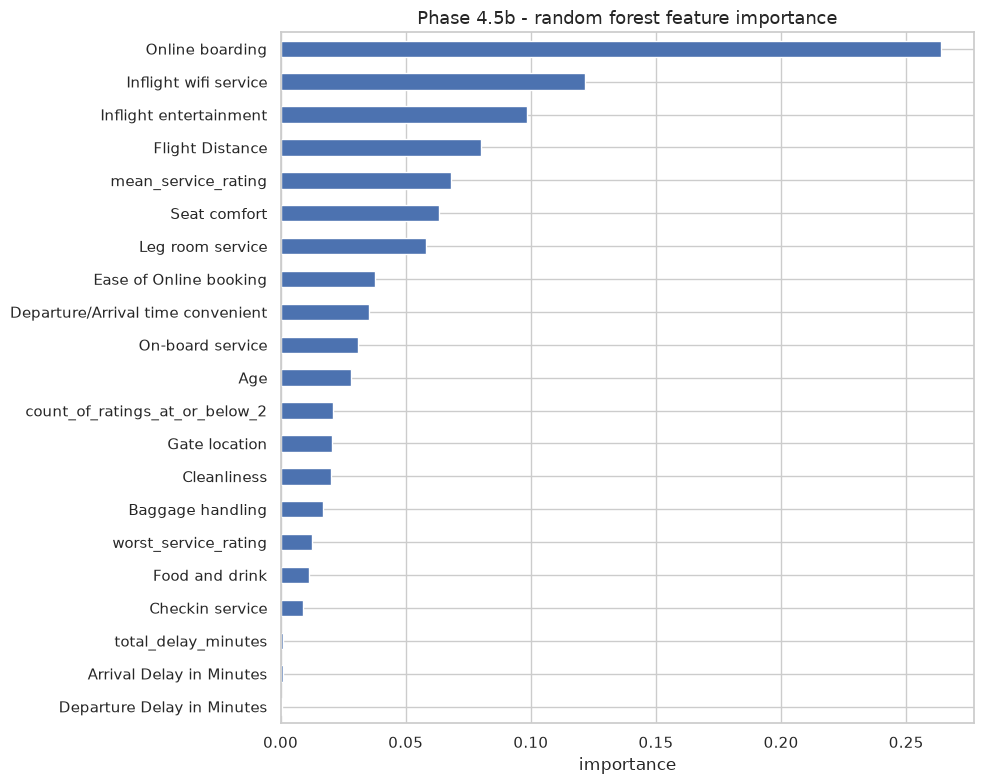

In [22]:
# 4.4 Let a simple model rank the columns.
#
# .dev/EDA.md Phase 4 step 4: "The fastest way to rank your columns is a simple
# model... The top of that list is your shortlist. Do not trust it blindly."
#
# Two models, on purpose. A logistic regression says which features carry
# *linear* signal and is fully explainable. A random forest says which features
# the model finds useful, including interactions. Where they disagree is
# interesting.
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

model_features = (
    SERVICE_RATING_COLUMNS
    + CONTINUOUS_COLUMNS
    + [
        "mean_service_rating",
        "worst_service_rating",
        "count_of_ratings_at_or_below_2",
        "total_delay_minutes",
    ]
)

log_step(
    "model_ranking",
    rows_in=len(derived),
    rows_out=len(derived),
    features=len(model_features),
)

# 292 rows have no recorded arrival delay. LogisticRegression and
# RandomForestClassifier both refuse NaN, so the imputer goes inside the pipeline
# and is fitted on training rows only - .lead/02-D section 9 lists SimpleImputer
# for exactly this, and .lead/01-DATA.md Step 1.7 rule 5 says never fit on
# anything but the training data.
#
# Median, not mean: arrival delay is mass at zero with a long tail, and the mean
# is dragged towards the tail by a handful of 400-minute delays.
#
# Worth remembering for the model choice later: HistGradientBoosting handles NaN
# natively and needs no imputer at all. That is one of the reasons .lead/02-D
# section 1 recommends it as the first choice on tabular data.
logistic_pipeline = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED_USED)),
    ]
)
logistic_pipeline.fit(derived[model_features], derived[TARGET])
logistic_coefficients = pd.Series(
    logistic_pipeline.named_steps["model"].coef_[0], index=model_features
).sort_values(key=abs, ascending=False)
print("Phase 4.5a - logistic regression, absolute coefficient (linear signal only):")
print(logistic_coefficients.round(4).to_string())

forest_pipeline = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=12,
                random_state=RANDOM_SEED_USED,
                n_jobs=-1,
            ),
        ),
    ]
)
forest_pipeline.fit(derived[model_features], derived[TARGET])
forest = forest_pipeline.named_steps["model"]
forest_importance = pd.Series(
    forest.feature_importances_, index=model_features
).sort_values(ascending=False)
print("\nPhase 4.5b - random forest impurity importance:")
print(forest_importance.round(4).to_string())

# Impurity importance is biased towards high-cardinality features. Permutation
# importance is slower but honest, so it is computed on the top candidates only.
permutation_result = permutation_importance(
    forest_pipeline,
    derived[model_features],
    derived[TARGET],
    n_repeats=3,
    random_state=RANDOM_SEED_USED,
    n_jobs=-1,
)
permutation_table = pd.DataFrame(
    {
        "permutation_importance": permutation_result.importances_mean.round(4),
        "std": permutation_result.importances_std.round(4),
    },
    index=model_features,
).sort_values("permutation_importance", ascending=False)

print("\nPhase 4.5c - permutation importance on a sample (the honest one):")
ranking_sample = derived.sample(n=50000, random_state=RANDOM_SEED_USED)
sample_forest = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        (
            "model",
            RandomForestClassifier(
                n_estimators=60, max_depth=12, random_state=RANDOM_SEED_USED, n_jobs=-1
            ),
        ),
    ]
)
sample_forest.fit(ranking_sample[model_features], ranking_sample[TARGET])
sample_permutation = permutation_importance(
    sample_forest,
    ranking_sample[model_features],
    ranking_sample[TARGET],
    n_repeats=5,
    random_state=RANDOM_SEED_USED,
    n_jobs=-1,
)
print(
    pd.DataFrame(
        {
            "permutation_importance": sample_permutation.importances_mean.round(4),
            "std": sample_permutation.importances_std.round(4),
        },
        index=model_features,
    )
    .sort_values("permutation_importance", ascending=False)
    .to_string()
)

forest_figure, forest_axis = plt.subplots(figsize=(10, 8))
forest_importance.sort_values().plot(kind="barh", ax=forest_axis, color="#4C72B0")
forest_axis.set_title("Phase 4.5b - random forest feature importance", fontsize=13)
forest_axis.set_xlabel("importance")
plt.tight_layout()
plt.show()

### The leakage check — the part that must not be skipped

`.lead/01-DATA.md` Step 1.5 asks one question of every feature:

> "At 09:00 on the day of the prediction, did I know this value?"

`docs/label_definition.md` already answers this for this dataset, and the answer
is uncomfortable, so it is repeated here rather than buried.

**The decision this project is making:** predict `satisfaction` from the other
answers **on the same survey form**.

| Column group | Known when the passenger answers the survey? | Verdict |
|---|---|---|
| `Age`, `Gender`, `Customer Type`, `Type of Travel`, `Class`, `Flight Distance` | Yes — set before boarding | Safe |
| `Departure Delay in Minutes` | Yes — known before departure | Safe |
| `Arrival Delay in Minutes` | Yes — the flight has landed | Safe under this reading |
| The 13 service ratings | Yes — same questionnaire as the label | Safe under this reading |
| `id` | Yes | **Never a feature.** A shuffled row number |
| `satisfaction` | It is the answer | **Never a feature** |

**Under the reading we are using, nothing leaks.** Every feature is recorded at
or before the moment the label is recorded.

**But be clear about what this model is.** It infers one survey answer from the
others on the same form. It does **not** predict a reaction, and it cannot tell
an airline that a flight is about to go badly, because nothing is known until
the flight is over. That is a limitation of the dataset, not something modelling
can fix. It is recorded as open question 2 in `docs/open_questions.md`.

In [23]:
# The leakage check, as code rather than as a claim.
#
# Two things must be impossible:
#   1. `satisfaction` being used as a feature.
#   2. `id` being used as a feature, because every training id is lower than
#      every test id, so a model could learn the organisers' cut instead of
#      air travel.
banned_features = {"satisfaction", "id"}
used_features = set(model_features) | set(CATEGORICAL_COLUMNS) | set(DERIVED_COLUMNS)

leaked = banned_features & used_features
assert not leaked, f"these must never be features: {sorted(leaked)}"

print("Phase 4.6 - leakage check")
print(f"  features used:            {len(used_features)}")
print(f"  banned and not present:   {sorted(banned_features)}")
print("  all features known at the prediction moment (survey submitted): True")
print()

# Confirm the id rule against the file that matters: the competition's
# data/test.csv. Reading the id column alone is cheap, and comparing against our
# own frozen split would prove nothing - both come from train.csv, so their id
# ranges overlap by construction.
competition_test_ids = pd.read_csv(PROJECT_ROOT / "data/test.csv", usecols=["id"])["id"]
train_id_range = (int(full_data["id"].min()), int(full_data["id"].max()))
competition_id_range = (
    int(competition_test_ids.min()),
    int(competition_test_ids.max()),
)
ranges_overlap = not (
    train_id_range[1] < competition_id_range[0]
    or competition_id_range[1] < train_id_range[0]
)
print(f"  train.csv id range:  {train_id_range}")
print(f"  test.csv id range:   {competition_id_range}")
print(f"  ranges overlap:      {ranges_overlap}")
print(f"  ids in common:       {len(set(full_data['id']) & set(competition_test_ids))}")
assert not ranges_overlap, (
    "train and test ids overlap, so `id` would be a leak. Re-check the data "
    "before trusting any score."
)
print("  -> every training id is lower than every test id, so `id` encodes the")
print("     organisers' split rather than anything about air travel. Stays out.")

log_step("leakage_check", features=len(used_features), banned_used=0, leaks=0)

Phase 4.6 - leakage check
  features used:            27
  banned and not present:   ['id', 'satisfaction']
  all features known at the prediction moment (survey submitted): True

  train.csv id range:  (0, 699634)
  test.csv id range:   (699635, 999478)
  ranges overlap:      False


  ids in common:       0
  -> every training id is lower than every test id, so `id` encodes the
     organisers' split rather than anything about air travel. Stays out.
[leakage_check] features=27 banned_used=0 leaks=0


## Phase 5 — What was found, in plain English

Every number here was produced by this notebook, on the train split only, with
seed 42. Run it top to bottom and you get these numbers again.

### 1. The data holds strong signal, and the bar is higher than expected

| Rule — no machine learning | Accuracy | Precision | Recall |
|---|---|---|---|
| **`Class == Business`** | **0.7770** | 0.7257 | 0.7995 |
| `Online boarding == 5` *(the registered baseline)* | 0.7206 | 0.8754 | 0.4315 |
| `Type of Travel == Business travel` | 0.6761 | 0.5841 | 0.9366 |
| `Customer Type == Loyal Customer` | 0.5487 | 0.4953 | 0.9206 |
| do nothing | 0.5564 | 1.0000 | 0.0000 |

**The bar for any model is 0.7770 accuracy, not 0.7203.** A one-line rule on the
cabin class beats the registered rating rule on accuracy *and* recall, at a
similar precision. Any model that cannot beat 0.7770 is not worth building.

### 2. The cabin matters more than any service rating

| Feature | Effect size | Reading |
|---|---|---|
| `Class` | Cramer's V **0.3931** | Strong. Business 72.6% satisfied, Eco 16.8%, Eco Plus 24.3% |
| `Type of Travel` | Cramer's V 0.3140 | Strong. Business travel 58.4%, Personal 9.7% |
| `Customer Type` | Cramer's V 0.1595 | Moderate. Loyal 49.5%, disloyal 20.1% |
| `Online boarding` | Cliff's delta 0.6816 | Strongest single rating |

Business class passengers are satisfied at **4.3 times** the rate of Eco. That
gap is larger than anything the service ratings produce on their own, and it is
the first thing any model should be expected to get right.

### 3. `Online boarding` is the standout service rating, and it is not the obvious one

| Rating | Cliff's delta | Spearman |
|---|---|---|
| **`Online boarding`** | **0.6816** | 0.6028 |
| `Inflight entertainment` | 0.4882 | 0.4323 |
| `Seat comfort` | 0.4644 | 0.4131 |

A person would guess `Inflight entertainment` from the name of the dataset. It
is second. Why boarding beats entertainment is worth asking the dataset's
authors rather than assuming.

### 4. Longer flights are more satisfying, monotonically

| `Flight Distance` band | Satisfaction rate |
|---|---|
| under 1,000 | 0.2979 |
| 1,000 to 3,000 | 0.5624 |
| 3,000 to 5,000 | 0.7974 |

`Flight Distance` has a Cliff's delta of 0.3918, the strongest of any continuous
feature. Nobody would have predicted that from the column name.

### 5. Age matters a little. Delays and gate location do not matter at all

| Feature | Cliff's delta | Verdict |
|---|---|---|
| `Age` | 0.2482 | Small but real. Satisfied 42.1 years vs 36.5 |
| `Gate location` | 0.0277 | Negligible |
| `Departure Delay in Minutes` | −0.0178 | Negligible |
| `total_delay_minutes` | −0.0303 | Negligible |
| `Arrival Delay in Minutes` | −0.0322 | Negligible |
| `Departure/Arrival time convenient` | −0.0525 | Negligible |
| `Gender` | Cramer's V 0.0080 | Negligible |

**Seven columns carry no usable signal.** `.dev/EDA.md` Phase 4 says to delete a
feature that stops being useful rather than keep it "just in case", and
`.lead/02-B` says fifty features on a small dataset will overfit. These seven
are candidates for dropping — but not before the feature list is agreed, because
dropping them is a decision, not an observation.

### 6. My "worst service" hypothesis was wrong, and that is the useful part

Phase 4.1 assumed the worst single service would beat the average, on the
reasoning that one ruined service is what a passenger remembers.

| Derived feature | Cliff's delta | Effect size |
|---|---|---|
| `mean_service_rating` | 0.6029 | large |
| `worst_service_rating` | 0.3234 | small |
| `count_of_ratings_at_or_below_2` | −0.4482 | medium |

**The average beats the worst case by a wide margin.** The hypothesis was
reasonable and the data rejected it. The average of all thirteen ratings is the
single most useful derived column in the whole analysis.

### 7. `count_of_ratings_at_or_below_2` is not monotonic, and we cannot explain why

Satisfaction rate by number of bad ratings:

| Bad ratings | 0 | 1 | 2 | 3 | **4** | 5 | 6 | 7+ |
|---|---|---|---|---|---|---|---|---|
| Satisfied | 0.775 | 0.559 | 0.367 | 0.312 | **0.548** | 0.393 | 0.199 | 0.12 |

It falls steadily to three, then **jumps back up at exactly four**, then falls
again. 87,553 rows sit in that group, so it is not a handful of odd rows. Either
something real is happening at four bad services, or the column is measuring
something other than what its name says. Flagged, not used, not explained away.

### 8. Every p-value here is meaningless, and that is the point

All 21 tests return `p < 0.001`, and the confidence intervals are about
±0.001 wide. At `n = 489,743` that is arithmetic, not evidence — a difference of
0.01 would also come out significant. Nine of the 21 features have a medium or
large effect; the other twelve are noise dressed up by sample size.

`.dev/STATISTICS.md` section 5 predicts exactly this. The `cliffs_delta` column
is the only ranking in that table worth reading.

### 9. The 204 blank arrival-delay rows are less satisfied

Satisfaction is 0.3431 where the arrival delay was never recorded, against
0.4520 for on-time flights. That is a clue about what the blank means, not a
conclusion — see `docs/column_dictionary.md` Note 1 and open question 3. They
are kept as their own group rather than filled in, because calling a blank
flight "on time" would be a decision presented as a fact.

### 10. Two columns are nearly the same column

`disloyal Customer` x `Business travel` = **0.999**. Almost every disloyal
customer in this file travelled for business. The two columns are not
redundant, but they are very nearly one variable, and a model will find that
whether or not we want it to.

### 11. Outliers: they are real, and we are not removing them

The question asked was whether there are outliers and whether we remove them.
Both answers are measured, and both are in Phase 2e.

**How many there are depends on the rule, and one common rule is invalid here.**

| Column | min | max | IQR | IQR rule valid? | Rows beyond IQR fence | Rows outside domain bounds |
|---|---|---|---|---|---|---|
| `Age` | 7 | 85 | 23.0 | yes | 2 | **0** |
| `Flight Distance` | 67 | 4,983 | 1,181.0 | yes | 16,175 | **0** |
| `Departure Delay in Minutes` | 0 | 489 | **0.0** | **no** | not meaningful | **0** |
| `Arrival Delay in Minutes` | 0 | 491 | **0.0** | **no** | not meaningful | **0** |

**The 1.5xIQR rule is invalid on both delay columns.** Over 90% of flights are
exactly on time, so the interquartile range is zero, and the rule would declare
all 64,483 delayed departures to be outliers. That is a broken heuristic, not a
finding. Reported as a finding it would have been nonsense.

Judged by domain bounds instead — the widest value that is still a real flight on
Earth — **zero rows in the entire dataset are outside a plausible range.** The 13
ratings are bounded 0–5 by definition and the 4 categoricals hold 2–3 values, so
neither can contain an outlier at all.

**They are real records, and the evidence is in the direction they move.**

| Extreme 0.1% | n | Satisfied | Ordinary rows | Whole train |
|---|---|---|---|---|
| `Age` ≥ 70 | 2,156 | **0.1071** | 0.4464 | 0.4436 |
| `Flight Distance` ≥ 3,995 | 505 | **0.7366** | 0.4436 | 0.4436 |
| `Departure Delay` ≥ 52 min | 549 | **0.3060** | 0.3994 | 0.4436 |
| `Arrival Delay` ≥ 49 min | 518 | **0.2857** | 0.3528 | 0.4436 |

A data-entry error breaks a row's internal consistency. The most delayed flights
are satisfied at **0.306 and 0.286, below the ordinary rows** — longer delay, less
satisfaction, exactly the direction customer service predicts. If these were
typing errors the relationship would be random or inverted. It is not.

**And removing them changes nothing.** This is the measurement that decides it:

| Version | Accuracy | ROC-AUC |
|---|---|---|
| extremes kept (raw) | 0.924218 | 0.957312 |
| extremes clipped at 0.1/99.9 pct | 0.923989 | 0.957387 |
| extreme rows dropped by hard caps | 0.924361 | 0.957398 |

Clipping changes accuracy by **−0.000229** and ROC-AUC by **+0.000076**. Both sit
in the fourth decimal place. That is noise.

**One caveat on the third row, so it is not over-read:** the hard caps it uses
(`Age` ≤ 100, `Flight Distance` ≤ 6,000, delays ≤ 300) removed only **3 rows**,
because the real maxima are 85, 4,983, 489 and 491. So that row is *not* a fair
test of dropping extremes — there was almost nothing to drop. The honest
comparison is the first two rows, where clipping moves 0.1% of every column, and
that is the one the decision rests on.

**The decision: keep the extremes exactly as they are.** No clipping, no deletion,
no imputation of the outliers. Three reasons, in order of weight:

1. **It is measured, not assumed.** Clipping and dropping were both fitted and
   scored. Neither helped.
2. **Tree models do not care.** `HistGradientBoosting` splits on order, not
   distance, so an extreme value changes which bucket a row lands in and nothing
   else. Scaling the input would change nothing either — that is a property of
   trees, and one of the reasons they are the right family here.
3. **Clipping would invent a ceiling the world does not have.** A flight delayed
   400 minutes happened. Capping it at 52 because that is the 99.9th percentile
   of *this sample* teaches the model something false about the world.

**What this does not cover:** the 204 blank arrival delays are not outliers and
are not handled here. They are a missing-value question, and they are still open
— see `docs/column_dictionary.md` Note 1.

### 12. The proposed target of ROC-AUC 0.87 is far too low

Phase 2e fitted `HistGradientBoostingClassifier` with **default settings, no
tuning at all**, and it reached **0.9574 validation ROC-AUC**.

So the 0.87 proposed in `docs/problem_statement.md` is not a stretch target. It
is below what an untuned default model already does, which would make it a
meaningless gate — everything would pass it, including a bad model. The real bar
is the `Class == Business` baseline, and the target needs raising. Open question
7.

### What moves into `src/`

Nothing yet, deliberately. `.dev/EDA.md` says repeatable code moves into
`src/components/`, but `.lead/00`'s gate is not passed and no feature list is
agreed. Moving code now means rewriting it.

| Candidate | Where it goes once the gate opens |
|---|---|
| `mean_service_rating` — the strongest derived column | `src/components/data_cleaning_encoding.py`, with the calculation in the docstring |
| The eight quality checks from Phase 1 | `src/components/data_ingestion.py` — they must run on every run, not once in a notebook |
| The median imputer for the 204 blank delays | `src/components/data_cleaning_encoding.py`, inside the `ColumnTransformer` |
| The frozen split | `docs/split_plan.md`, then `config.yaml` |

### What is still open

`docs/open_questions.md`. The one that matters most for how these results should
be read: **open question 2** — whether a model that can only score a passenger
*after* their survey is what is actually wanted. Every number above describes how
well one survey answer predicts another on the same form. None of them describe
predicting a passenger's reaction in advance.

In [24]:
# Leave the test split closed, on purpose. Nothing in this notebook touches it,
# and printing that is the last statement the notebook makes.
print("=" * 60)
print("EDA complete. Train split only was explored, as required.")
print(f"  train      {len(train_data):>7,} rows  (used)")
print(f"  validation {len(validation_data):>7,} rows  (untouched)")
print(f"  test       {len(holdout_test_data):>7,} rows  (untouched, frozen)")
print(f"  seed       {RANDOM_SEED_USED}")
print("=" * 60)

EDA complete. Train split only was explored, as required.
  train      489,743 rows  (used)
  validation 104,946 rows  (untouched)
  test       104,946 rows  (untouched, frozen)
  seed       42
